In [ ]:
#! pip install pandas
#! pip install matplotlib
#! pip install scipy
#! pip install seaborn
#! pip install nbconvert
#! pip install matplotlib-venn
#! jupyter nbconvert --to HTML PoseErrorAnalysis.ipynb
#! pip install scour

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import griddata
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt
import seaborn as sns
import numba

sys.path.append("../../")  # from src/notebooks/pose_analysis to src/

from util.datapipeline.EmbeddingDataset import EmbeddingDataset

pd.set_option('display.max_columns', None)

In [ ]:
def compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=""):


    # ------------------------------------------------------------
    # Pose grid
    # ------------------------------------------------------------
    _, _, _, _, poses_ref = dataset_query[0]
    poses_ref = np.array([tuple(map(int, p)) for p in poses_ref])

    pitches = np.unique(poses_ref[:,0])
    yaws = np.unique(poses_ref[:,1])

    H = len(pitches)
    W = len(yaws)

    pitch_to_idx = {p:i for i,p in enumerate(pitches)}
    yaw_to_idx   = {y:j for j,y in enumerate(yaws)}

    grid_pitch, grid_yaw = np.meshgrid(pitches, yaws, indexing="ij")
    grid_points = np.stack([grid_pitch.ravel(), grid_yaw.ravel()], axis=1)

    cache_file = f"{prefix}_mrr_heatmap_cache.npz"
    if os.path.exists(cache_file):
        print("Loading cached heatmap:", cache_file)
        data = np.load(cache_file)
        mrr_sum = data["mrr_sum"]
        counts = data["counts"]
        heatmap_mrr = (mrr_sum / np.maximum(counts,1)) * 100
    else:
        # ------------------------------------------------------------
        # Collect ENROLLED frontal embeddings only
        # ------------------------------------------------------------
        enrolled_embeddings = []
        enrolled_labels = []

        for emb, label, _, _, poses in tqdm(dataset_enrolled, desc="Prepare Enrolled"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int, p)) for p in poses]

            for e, p in zip(emb, poses):
                pitch, yaw = p

                if pitch == 0 and yaw == 0:
                    enrolled_embeddings.append(e)
                    enrolled_labels.append(label)

        enrolled_embeddings = np.stack(enrolled_embeddings)
        enrolled_labels = np.array(enrolled_labels)
        
        enrolled_T = enrolled_embeddings.T # Precompute transpose for fast dot product

        # ------------------------------------------------------------
        # Pose accumulators
        # ------------------------------------------------------------
        mrr_sum = np.zeros((H,W), dtype=np.float32)
        counts  = np.zeros((H,W), dtype=np.int32)

        # ------------------------------------------------------------
        # Process QUERY one sample at a time
        # ------------------------------------------------------------
        for emb, label, _, _, poses in tqdm(dataset_query, desc="Processing Queries"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int,p)) for p in poses]

            for e, p in zip(emb, poses):

                pitch, yaw = p

                i = pitch_to_idx[pitch]
                j = yaw_to_idx[yaw]

                sims = np.dot(e, enrolled_T)

                ranked = np.argsort(-sims)

                gt_indices = np.where(enrolled_labels == label)[0]
                ranks = np.where(np.isin(ranked, gt_indices))[0]

                if len(ranks) > 0:
                    rr = 1.0 / (ranks[0] + 1)
                else:
                    rr = 0.0

                mrr_sum[i,j] += rr
                counts[i,j] += 1

        heatmap_mrr = (mrr_sum / np.maximum(counts,1)) * 100

        np.savez_compressed(
            cache_file,
            mrr_sum=mrr_sum,
            counts=counts,
        )

    print("Saved heatmap cache:", cache_file)

    # ------------------------------------------------------------
    # Pose → heatmap index mapping (for visualization)
    # ------------------------------------------------------------
    pitch_to_idx = {p: i for i, p in enumerate(pitches)}
    yaw_to_idx   = {y: j for j, y in enumerate(yaws)}

    pose_y = np.array([pitch_to_idx[p] for p, _ in poses_ref])
    pose_x = np.array([yaw_to_idx[y]   for _, y in poses_ref])

    # ------------------------------------------------------------
    # Interpolation
    # ------------------------------------------------------------
    valid = counts.ravel() > 0
    points = grid_points[valid]                 # (N,2)
    values = np.divide(
        mrr_sum.ravel(),
        counts.ravel(),
        out=np.zeros_like(mrr_sum.ravel(), dtype=float),
        where=counts.ravel() > 0
    )[valid] * 100
    interp_mrr = LinearNDInterpolator(points, values, fill_value=np.nan)
    heatmap_mrr = interp_mrr(grid_points).reshape(H, W)

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------
    if visualize:

        # --------------------------------------------------------
        # Build validity mask from raw interpolated values
        # --------------------------------------------------------
        raw_mrr = interp_mrr(grid_points).reshape(H, W)
        valid_mask = ~np.isnan(raw_mrr)
        heat_mrr_plot = np.ma.masked_where(~valid_mask, raw_mrr)

        plt.rcParams.update({
            "font.size": 16,
            "axes.titlesize": 26,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
        })

        cmap_main = plt.cm.viridis.copy()
        cmap_main.set_bad(color="white")

        fig1, ax1 = plt.subplots(figsize=(22, 20))
        vmax = np.nanmax(np.abs(heat_mrr_plot))
        vmin = np.nanmin(np.abs(heat_mrr_plot))
        sns.heatmap(
            heat_mrr_plot,
            ax=ax1,
            xticklabels=yaws,
            yticklabels=pitches,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap_main,
            square=True,
            cbar_kws={"shrink": 0.8, "label": "MRR"}
        )
        
        threshold = vmin + 0.25 * (vmax - vmin)
        for x, y in zip(pose_x, pose_y):
            if x == 55:
                if y % 2 != 1:
                    continue
            if y == 35:
                if x % 2 != 1:
                    continue
            val = heatmap_mrr[y, x]
            text_color = "white" if val < threshold else "black"
            ax1.text(
                x + 0.5, y + 0.5,
                f"{val:.0f}",
                ha="center",
                va="center",
                fontsize=11,
                color=text_color
            )

        ax1.set_title("Single View 1:N FR with Enrolled (0,0) and Query based on Pose in MRR")
        ax1.set_xlabel("Yaw")
        ax1.set_ylabel("Pitch")
        # show only every 5th tick label
        for i, label in enumerate(ax1.get_xticklabels()):
            if i % 5 != 0:
                label.set_visible(False)
        for i, label in enumerate(ax1.get_yticklabels()):
            if i % 5 != 0:
                label.set_visible(False)

        plt.savefig(f"{prefix}_mrr_heatmap.svg", bbox_inches="tight")
        plt.savefig(f"{prefix}_mrr_heatmap.jpg", dpi=200, bbox_inches="tight")

        plt.show()

    return heatmap_mrr, pitches, yaws

### Headpose aligned comparison

In [ ]:
def compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=""):

    # ------------------------------------------------------------
    # Pose grid
    # ------------------------------------------------------------
    _, _, _, _, poses_ref = dataset_query[0]
    poses_ref = np.array([tuple(map(int, p)) for p in poses_ref])

    pitches = np.unique(poses_ref[:,0])
    yaws = np.unique(poses_ref[:,1])

    H = len(pitches)
    W = len(yaws)

    pitch_to_idx = {p:i for i,p in enumerate(pitches)}
    yaw_to_idx   = {y:j for j,y in enumerate(yaws)}

    grid_pitch, grid_yaw = np.meshgrid(pitches, yaws, indexing="ij")
    grid_points = np.stack([grid_pitch.ravel(), grid_yaw.ravel()], axis=1)

    # ------------------------------------------------------------
    # Pose → heatmap index mapping
    # ------------------------------------------------------------
    pose_y = np.array([pitch_to_idx[p] for p, _ in poses_ref])
    pose_x = np.array([yaw_to_idx[y]   for _, y in poses_ref])

    cache_file = f"{prefix}_mrr_heatmap_cache_samepose.npz"
    if os.path.exists(cache_file):
        print("Loading cached heatmap:", cache_file)
        data = np.load(cache_file)
        mrr_sum = data["mrr_sum"]
        counts = data["counts"]
        heatmap_mrr = (mrr_sum / np.maximum(counts,1)) * 100
    else:
        # ------------------------------------------------------------
        # Collect ENROLLED embeddings grouped by pose
        # ------------------------------------------------------------
        pose_to_embeddings = {}
        pose_to_labels = {}
        pose_to_T = {}

        for emb, label, _, _, poses in tqdm(dataset_enrolled, desc="Prepare Enrolled"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int, p)) for p in poses]

            for e, p in zip(emb, poses):

                if p not in pose_to_embeddings:
                    pose_to_embeddings[p] = []
                    pose_to_labels[p] = []

                pose_to_embeddings[p].append(e)
                pose_to_labels[p].append(label)

        # convert to numpy + precompute transpose
        for p in pose_to_embeddings:
            pose_to_embeddings[p] = np.stack(pose_to_embeddings[p])
            pose_to_labels[p] = np.array(pose_to_labels[p])
            pose_to_T[p] = pose_to_embeddings[p].T

        # ------------------------------------------------------------
        # Pose accumulators
        # ------------------------------------------------------------
        mrr_sum = np.zeros((H,W), dtype=np.float32)
        counts  = np.zeros((H,W), dtype=np.int32)

        # ------------------------------------------------------------
        # Process QUERY
        # ------------------------------------------------------------
        for emb, label, _, _, poses in tqdm(dataset_query, desc="Processing Queries"):

            emb = F.normalize(emb, dim=-1).cpu().numpy()
            poses = [tuple(map(int,p)) for p in poses]

            for e, p in zip(emb, poses):

                if p not in pose_to_embeddings:
                    continue

                pitch, yaw = p

                i = pitch_to_idx[pitch]
                j = yaw_to_idx[yaw]

                enrolled_T = pose_to_T[p]
                enrolled_labels = pose_to_labels[p]

                sims = np.dot(e, enrolled_T)

                ranked = np.argsort(-sims)

                gt_indices = np.where(enrolled_labels == label)[0]
                ranks = np.where(np.isin(ranked, gt_indices))[0]

                if len(ranks) > 0:
                    rr = 1.0 / (ranks[0] + 1)
                else:
                    rr = 0.0

                mrr_sum[i,j] += rr
                counts[i,j] += 1

        heatmap_mrr = (mrr_sum / np.maximum(counts,1)) * 100

        np.savez_compressed(
            cache_file,
            mrr_sum=mrr_sum,
            counts=counts
        )

        print("Saved heatmap cache:", cache_file)

    # ------------------------------------------------------------
    # Interpolation
    # ------------------------------------------------------------
    valid = counts.ravel() > 0
    points = grid_points[valid]
    values = np.divide(
        mrr_sum.ravel(),
        counts.ravel(),
        out=np.zeros_like(mrr_sum.ravel(), dtype=float),
        where=counts.ravel() > 0
    )[valid] * 100

    interp_mrr = LinearNDInterpolator(points, values, fill_value=np.nan)

    heatmap_mrr = interp_mrr(grid_points).reshape(H, W)

    # ------------------------------------------------------------
    # Visualization
    # ------------------------------------------------------------
    if visualize:

        raw_mrr = interp_mrr(grid_points).reshape(H, W)

        valid_mask = ~np.isnan(raw_mrr)
        heat_mrr_plot = np.ma.masked_where(~valid_mask, raw_mrr)

        plt.rcParams.update({
            "font.size": 16,
            "axes.titlesize": 26,
            "xtick.labelsize": 18,
            "ytick.labelsize": 18,
        })

        cmap_main = plt.cm.viridis.copy()
        cmap_main.set_bad(color="white")

        fig1, ax1 = plt.subplots(figsize=(22, 20))

        vmax = np.nanmax(np.abs(heat_mrr_plot))
        vmin = np.nanmin(np.abs(heat_mrr_plot))

        sns.heatmap(
            heat_mrr_plot,
            ax=ax1,
            xticklabels=yaws,
            yticklabels=pitches,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap_main,
            square=True,
            cbar_kws={"shrink": 0.8, "label": "MRR (%)"}
        )
        
        threshold = vmin + 0.25 * (vmax - vmin)
        for x, y in zip(pose_x, pose_y):
            if x == 55:
                if y % 2 != 1:
                    continue
            if y == 35:
                if x % 2 != 1:
                    continue
            val = heatmap_mrr[y, x]
            text_color = "white" if val < threshold else "black"
            ax1.text(
                x + 0.5, y + 0.5,
                f"{val:.0f}",
                ha="center",
                va="center",
                fontsize=11,
                color=text_color
        )

        ax1.set_title("Single View 1:N FR with Pose-Aligned Enrolled and Query in MRR")
        ax1.set_xlabel("Yaw")
        ax1.set_ylabel("Pitch")

        for i, label in enumerate(ax1.get_xticklabels()):
            if i % 5 != 0:
                label.set_visible(False)

        for i, label in enumerate(ax1.get_yticklabels()):
            if i % 5 != 0:
                label.set_visible(False)

        plt.savefig(f"{prefix}_mrr_heatmap_samepose.svg", bbox_inches="tight")
        plt.savefig(f"{prefix}_mrr_heatmap_samepose.jpg", dpi=200, bbox_inches="tight")

        plt.show()

    return heatmap_mrr, pitches, yaws

Loading classes: 100%|██████████| 1041/1041 [03:09<00:00,  5.50it/s]


Loading cached heatmap: test_rgb_bff_crop305_emb-edgeface_xs_mrr_heatmap_cache.npz
Saved heatmap cache: test_rgb_bff_crop305_emb-edgeface_xs_mrr_heatmap_cache.npz


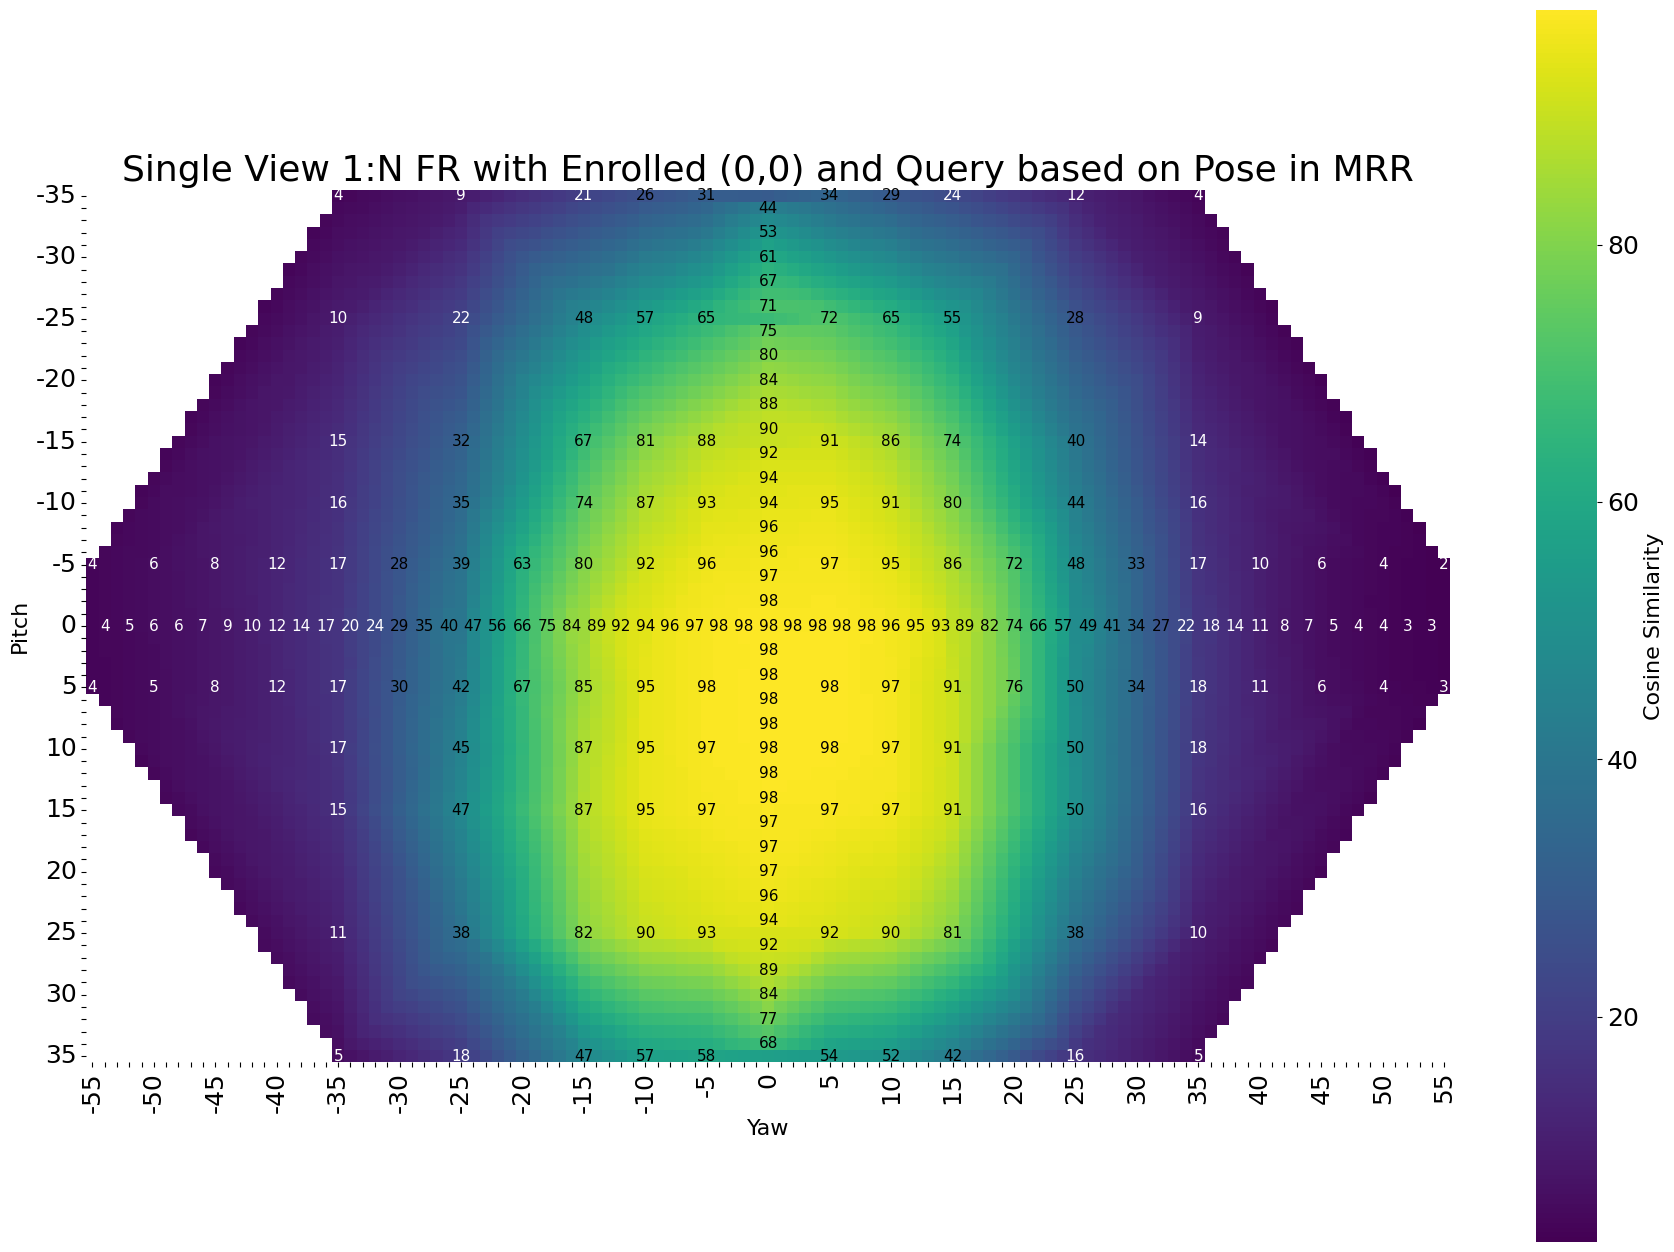

Loading cached heatmap: test_rgb_bff_crop305_emb-edgeface_xs_mrr_heatmap_cache_samepose.npz


C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


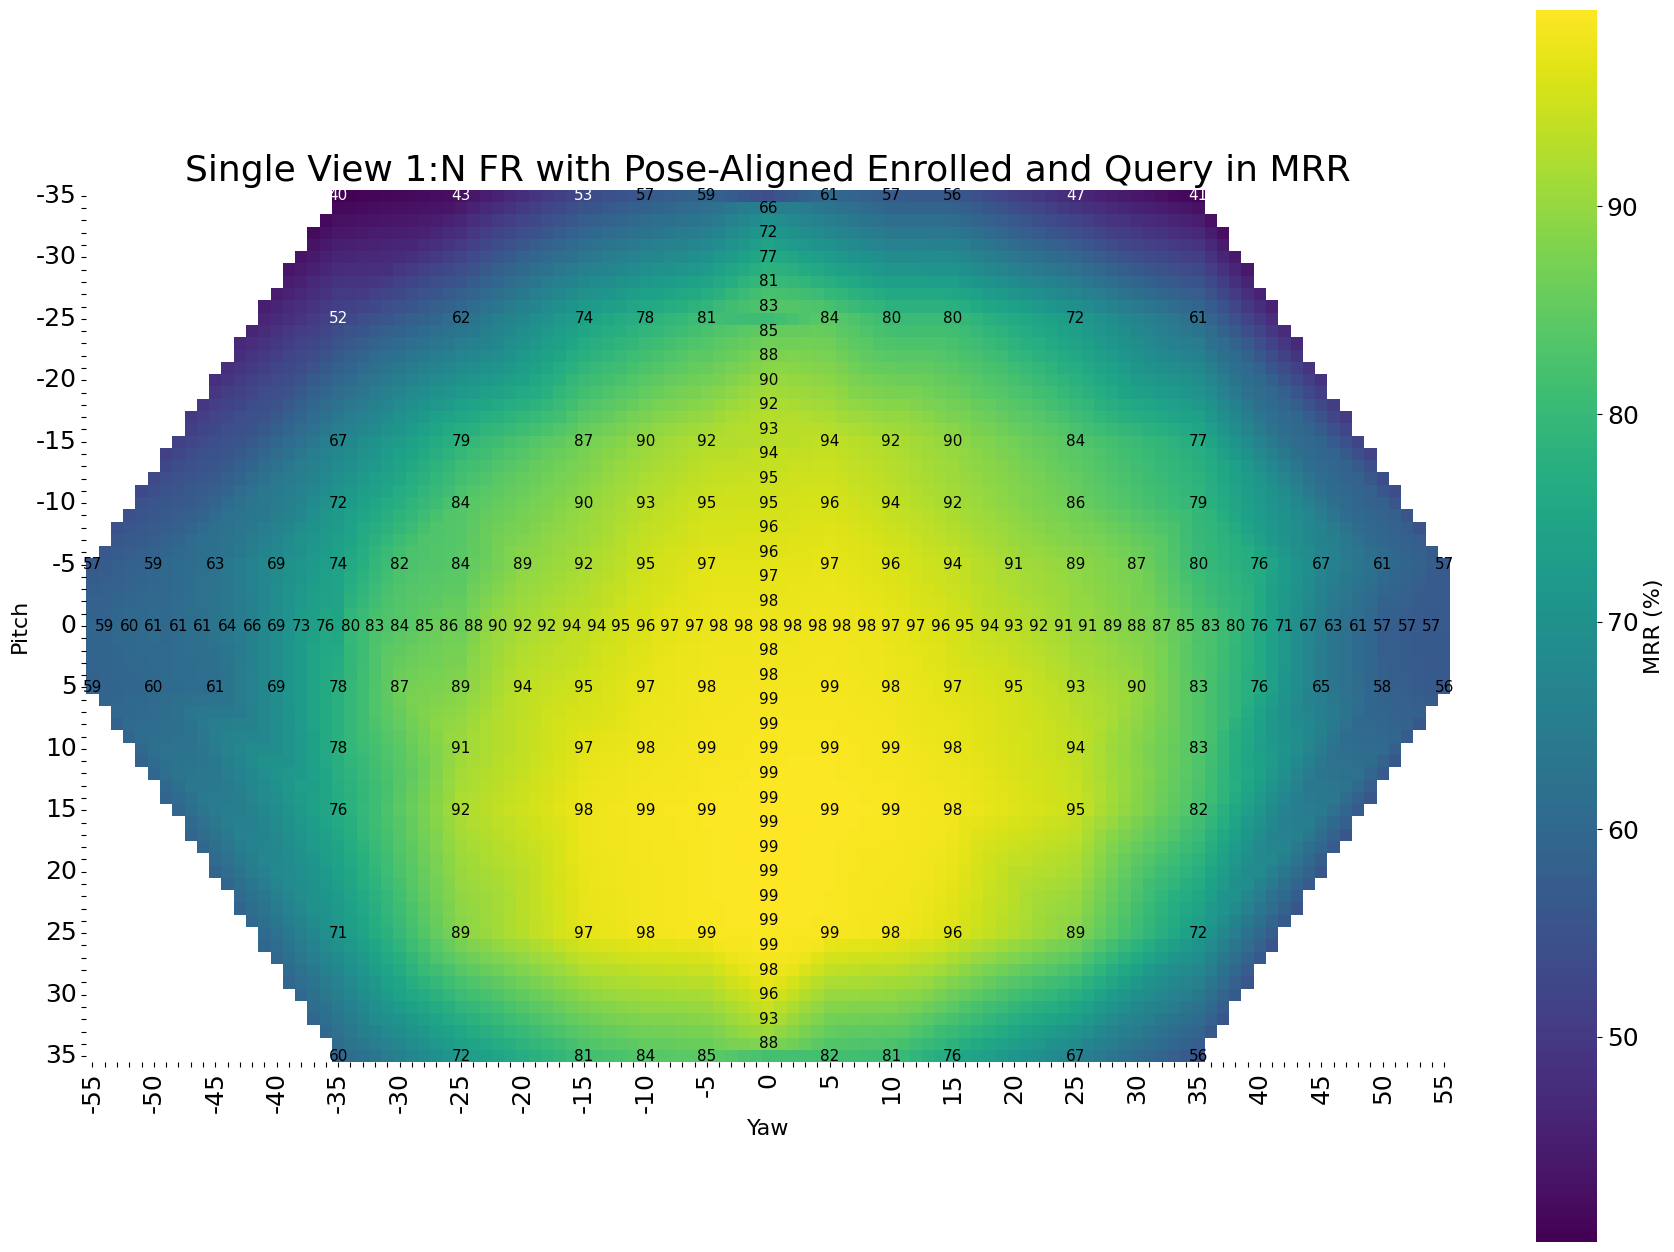

In [6]:
name="test_rgb_bff_crop305_emb-edgeface_xs"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [19:52<00:00, 15.72it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-adaface_webface12m_mrr_heatmap_cache.npz


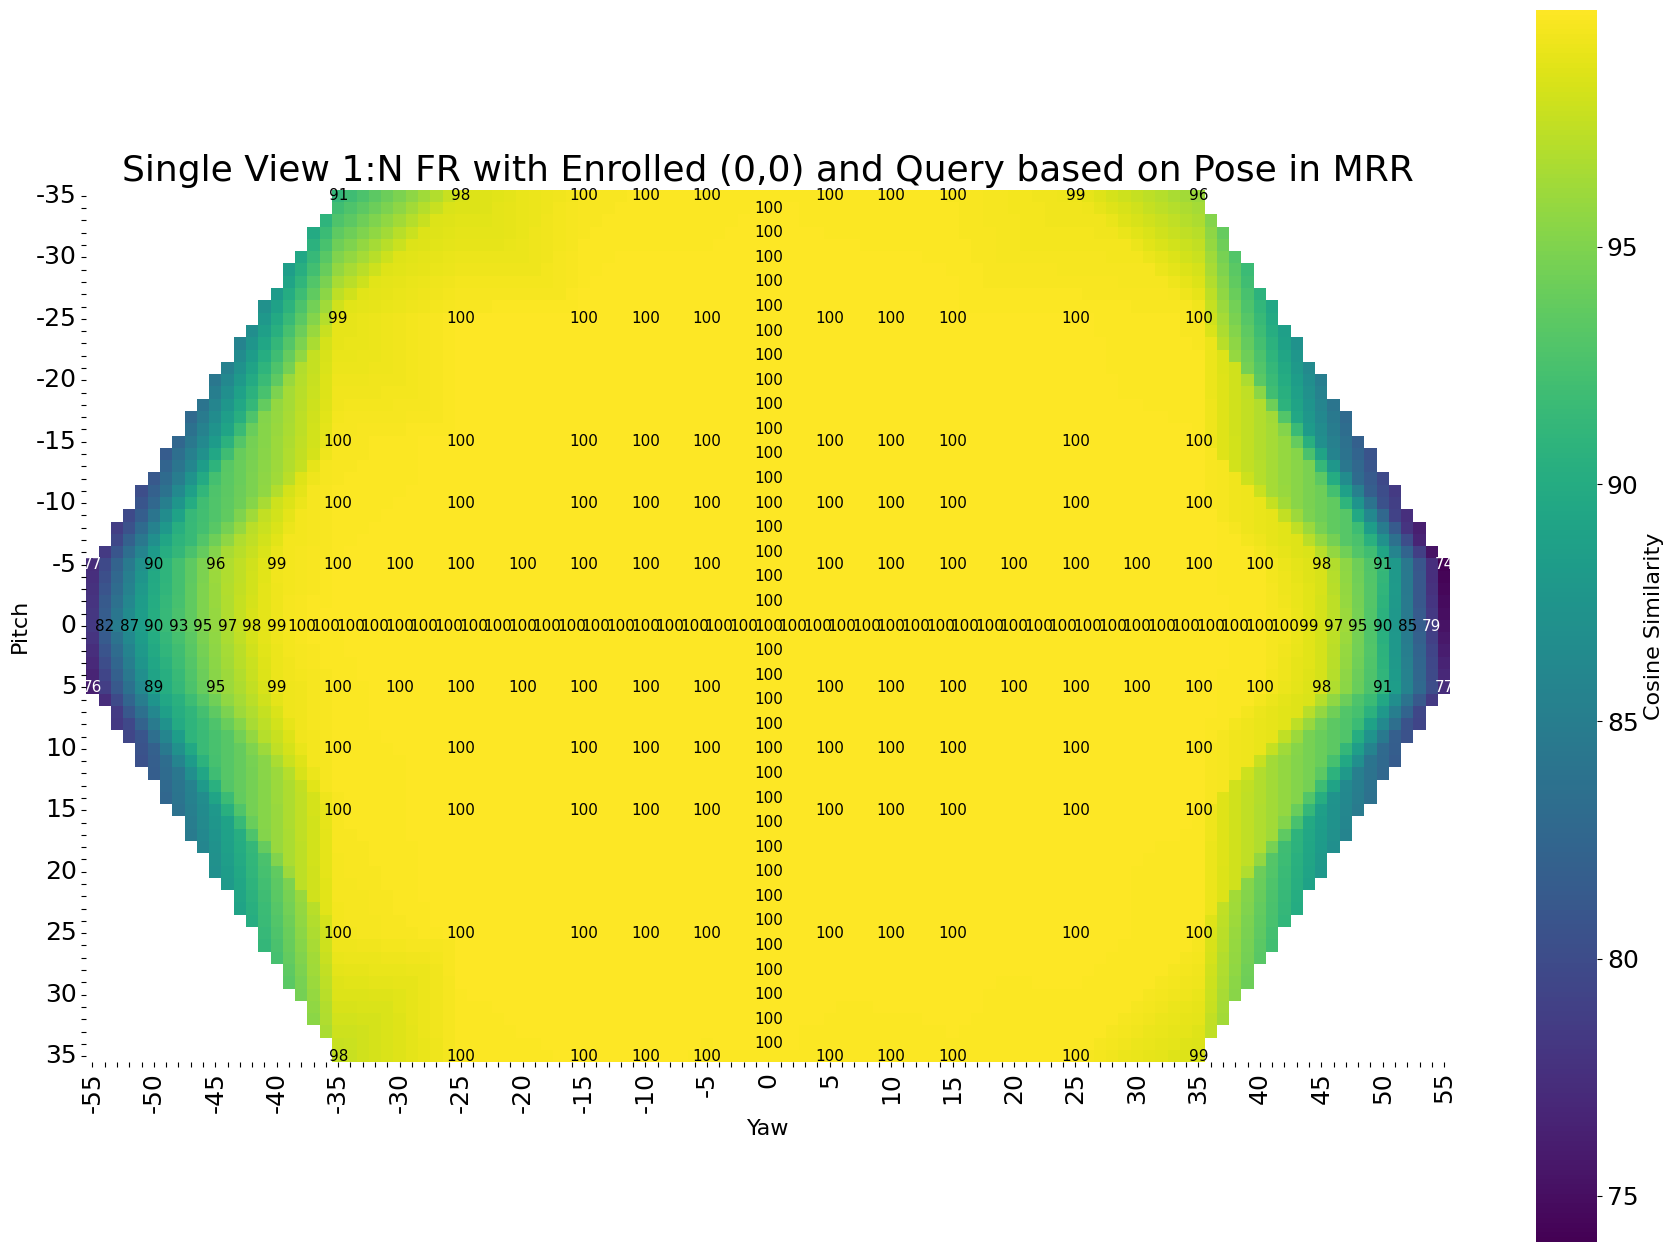

Processing Queries: 100%|██████████| 18745/18745 [22:05<00:00, 14.15it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-adaface_webface12m_mrr_heatmap_cache_samepose.npz


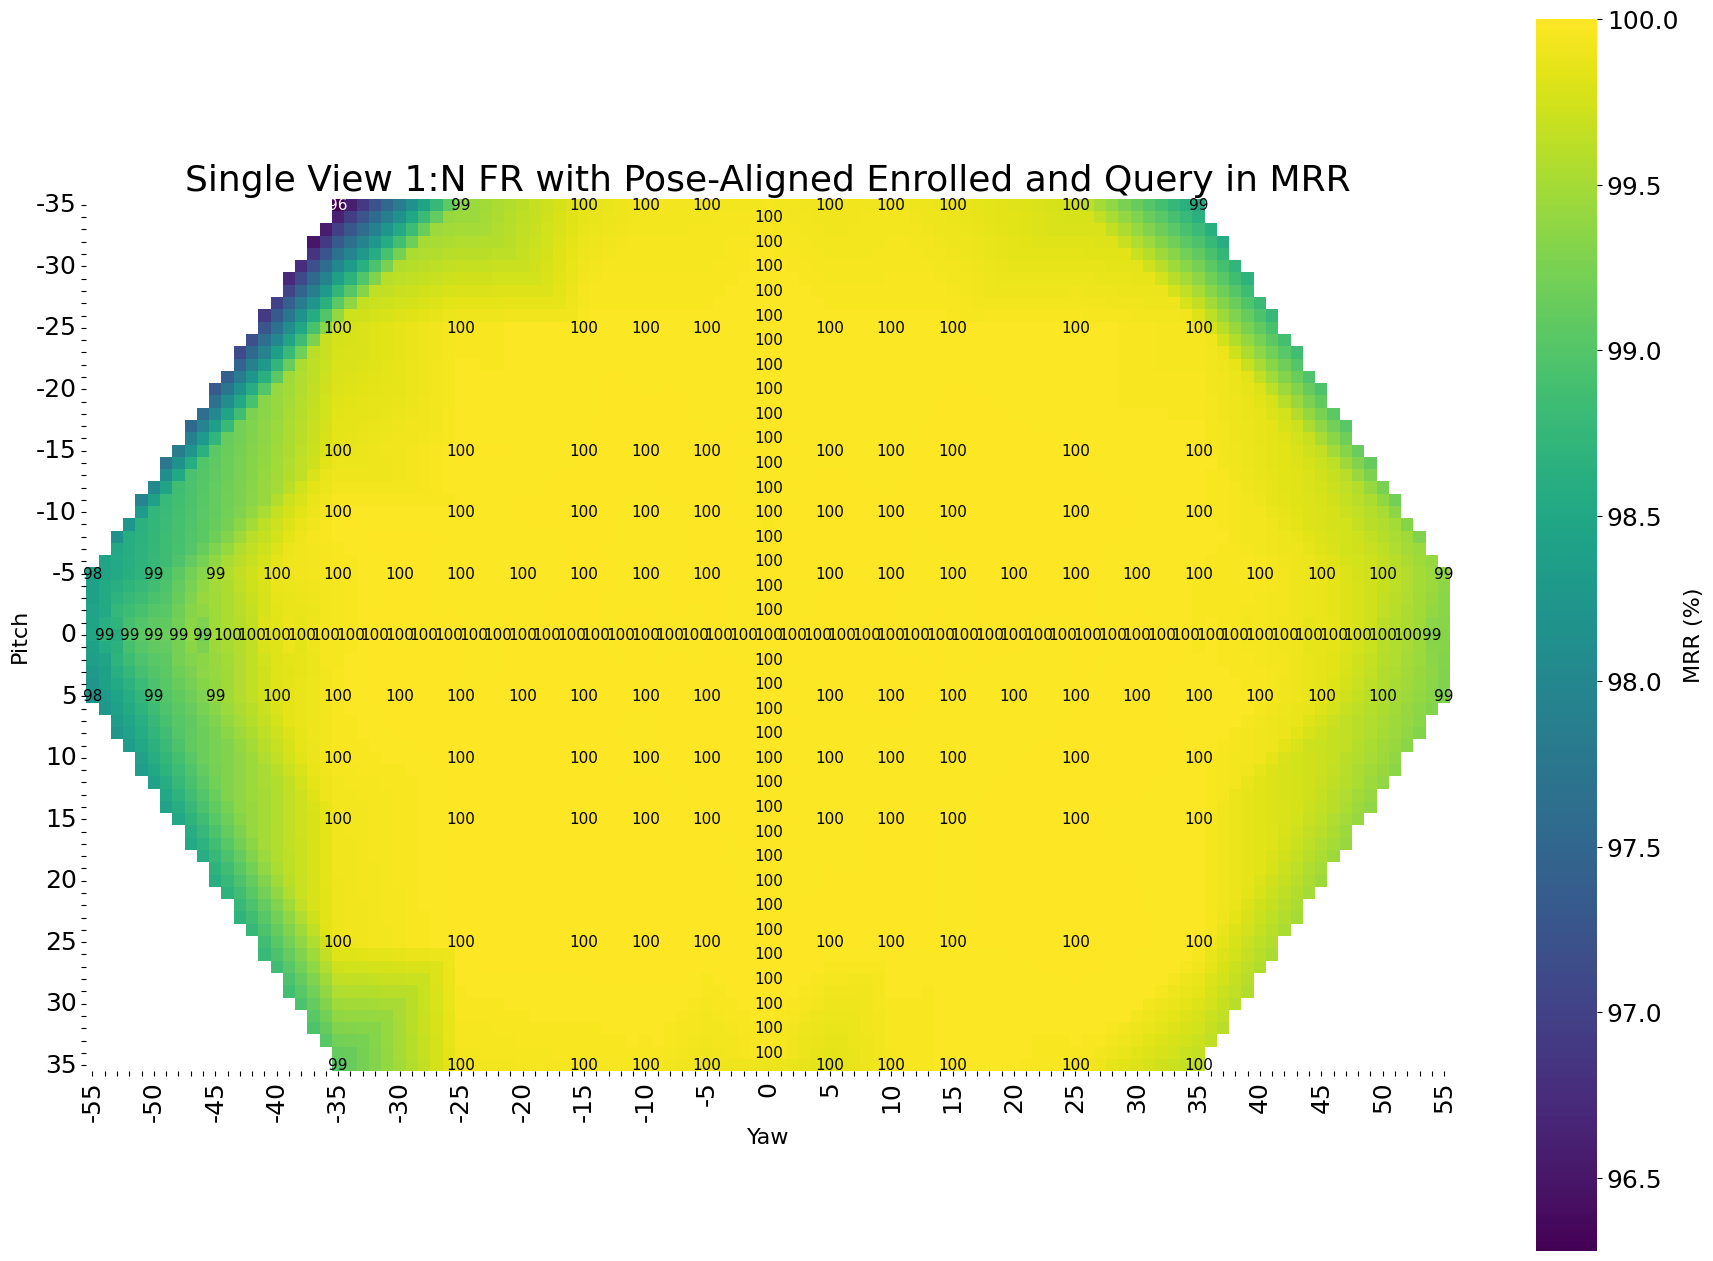

In [7]:
name="test_rgb_bff_crop305_emb-adaface_webface12m"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [19:06<00:00, 16.34it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r18_mrr_heatmap_cache.npz


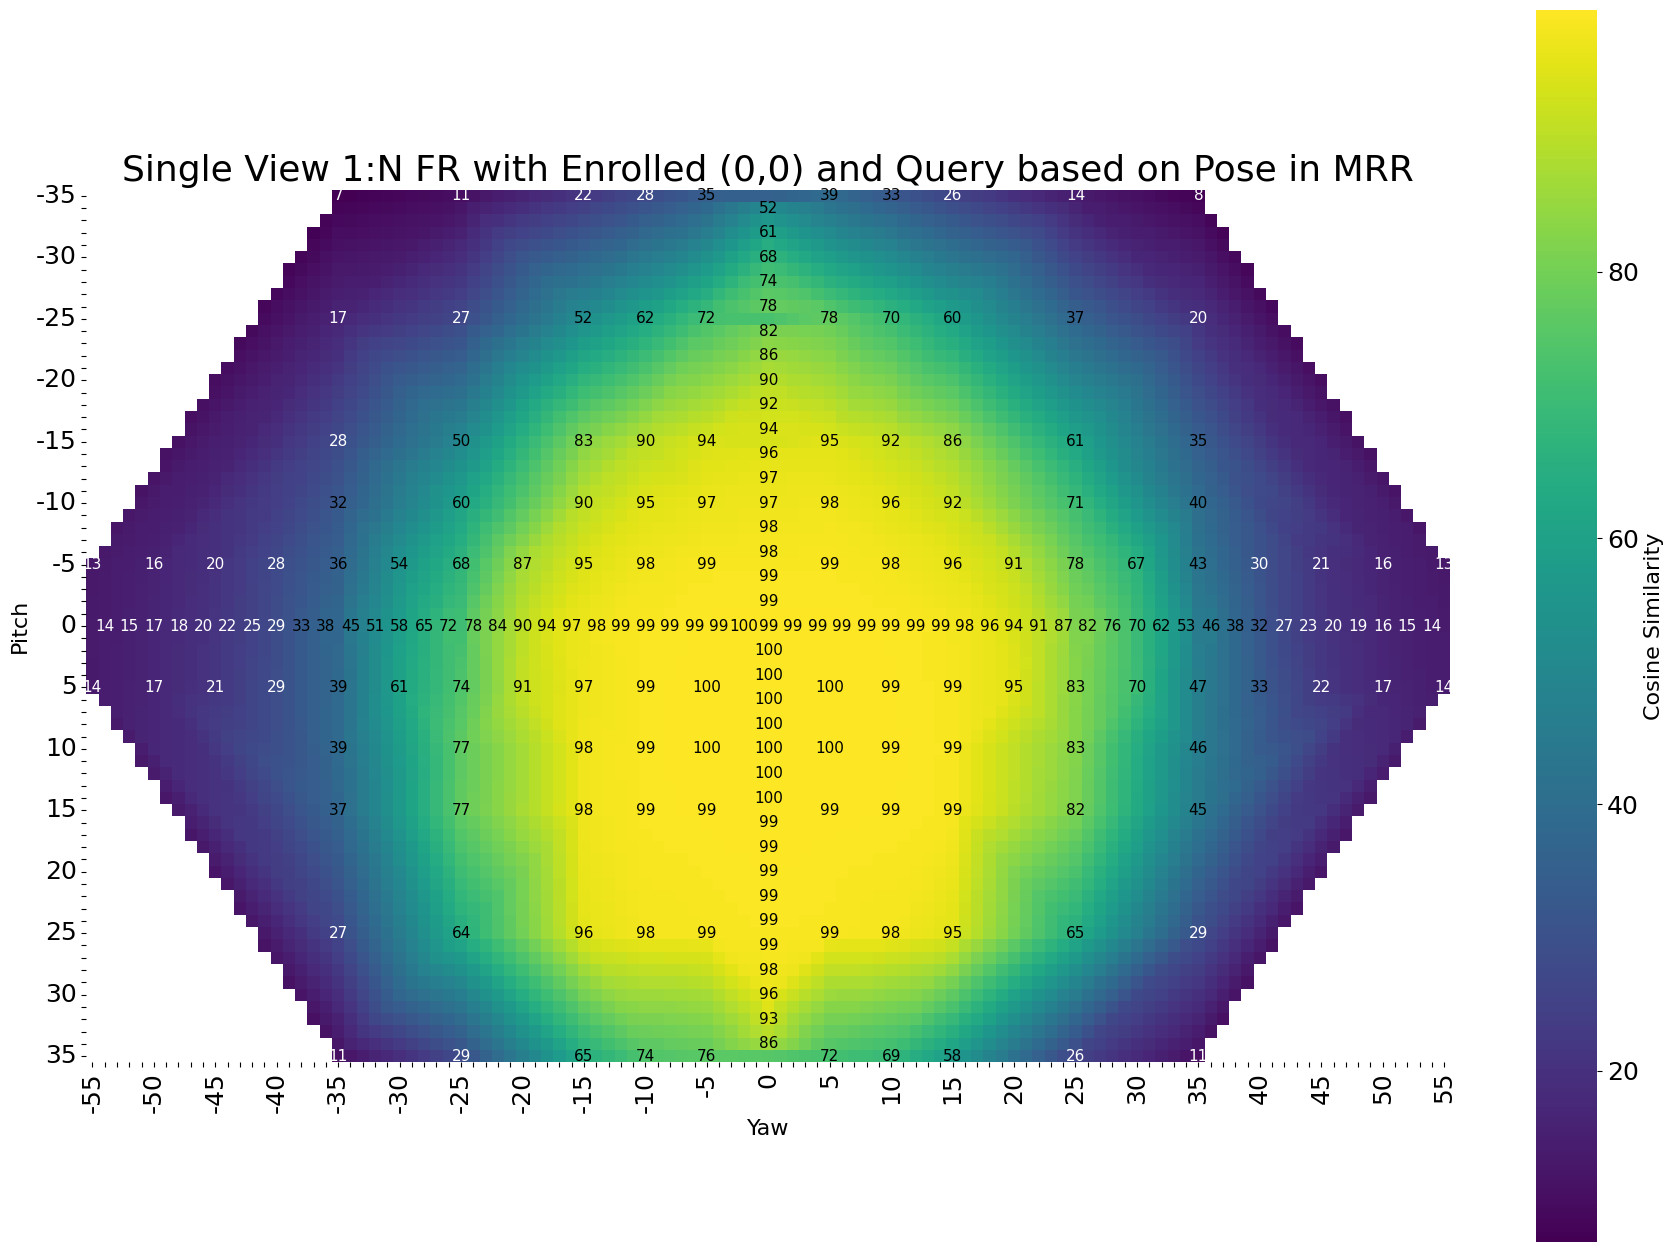

Processing Queries: 100%|██████████| 18745/18745 [22:01<00:00, 14.18it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r18_mrr_heatmap_cache_samepose.npz


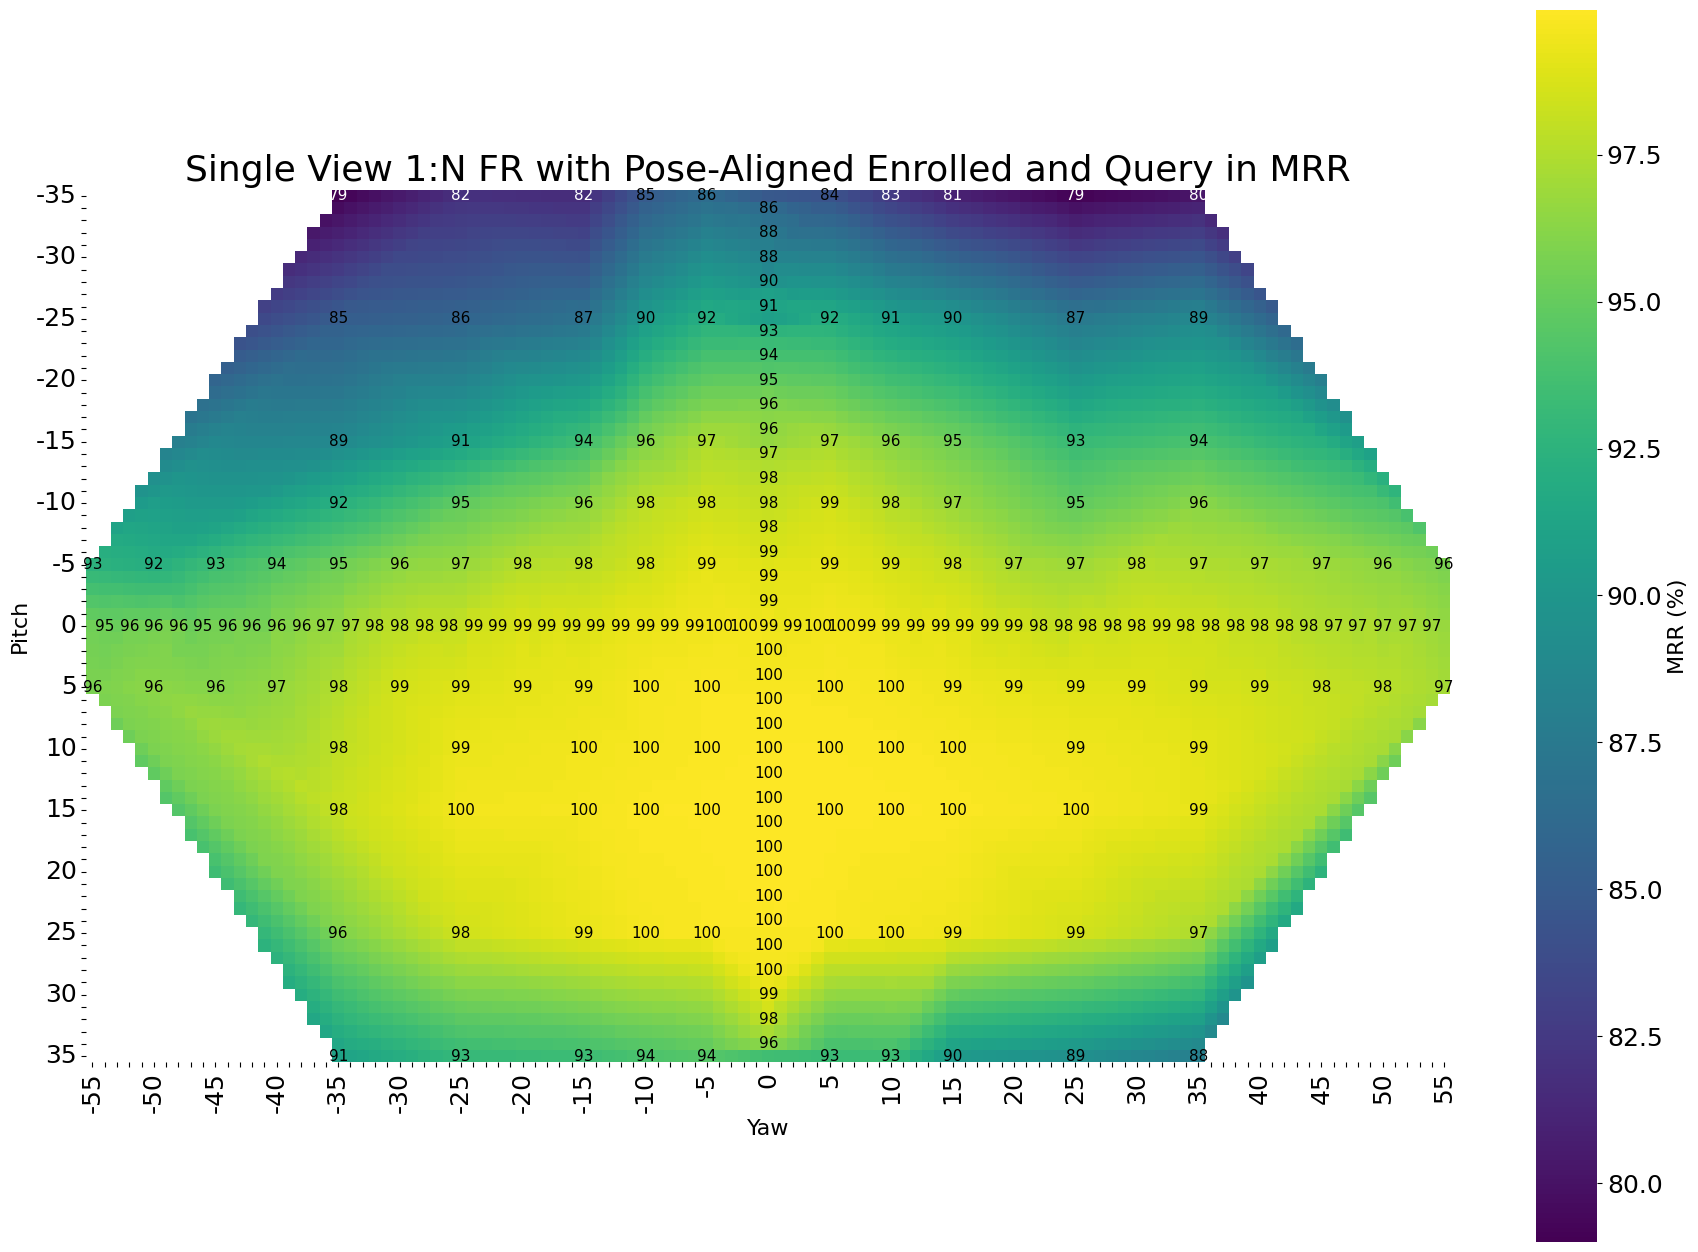

In [8]:
name="test_rgb_bff_crop305_emb-glint_r18"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [20:46<00:00, 15.04it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r50_mrr_heatmap_cache.npz


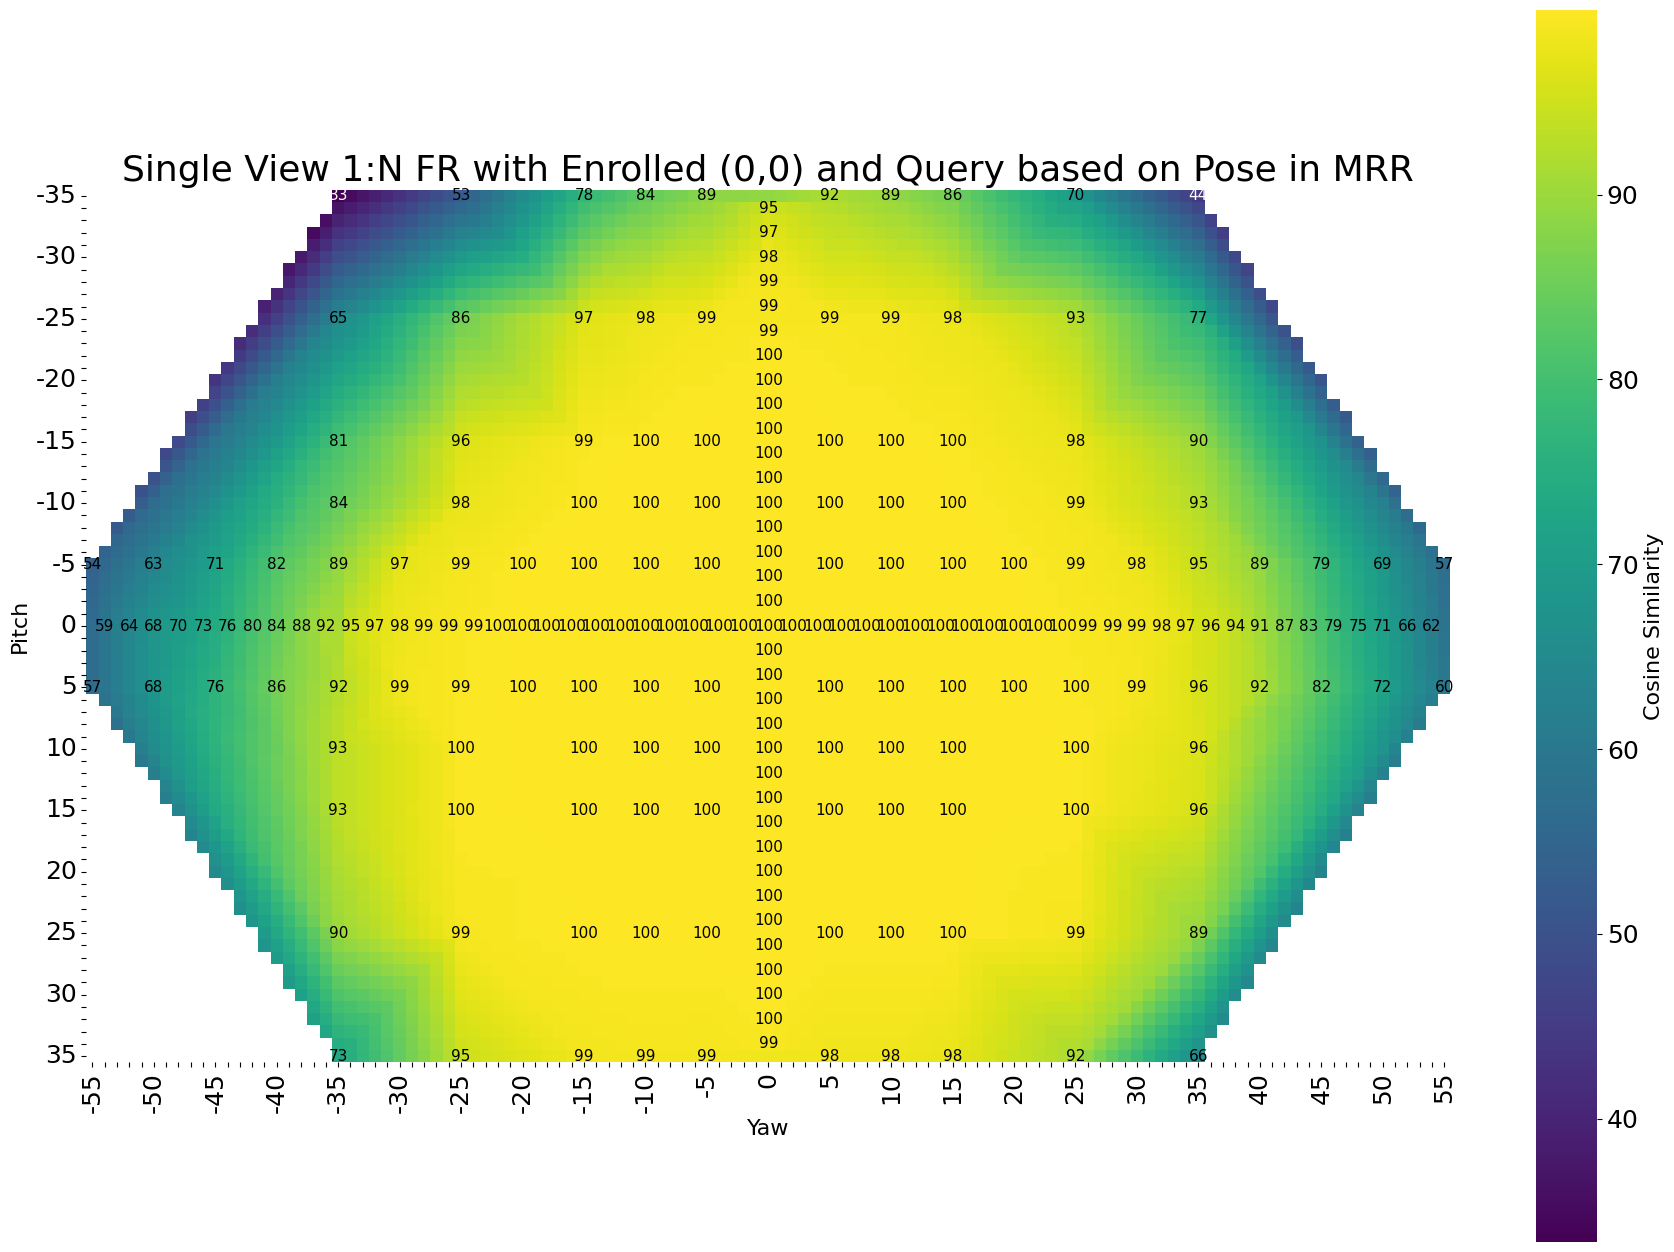

Processing Queries: 100%|██████████| 18745/18745 [23:46<00:00, 13.14it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r50_mrr_heatmap_cache_samepose.npz


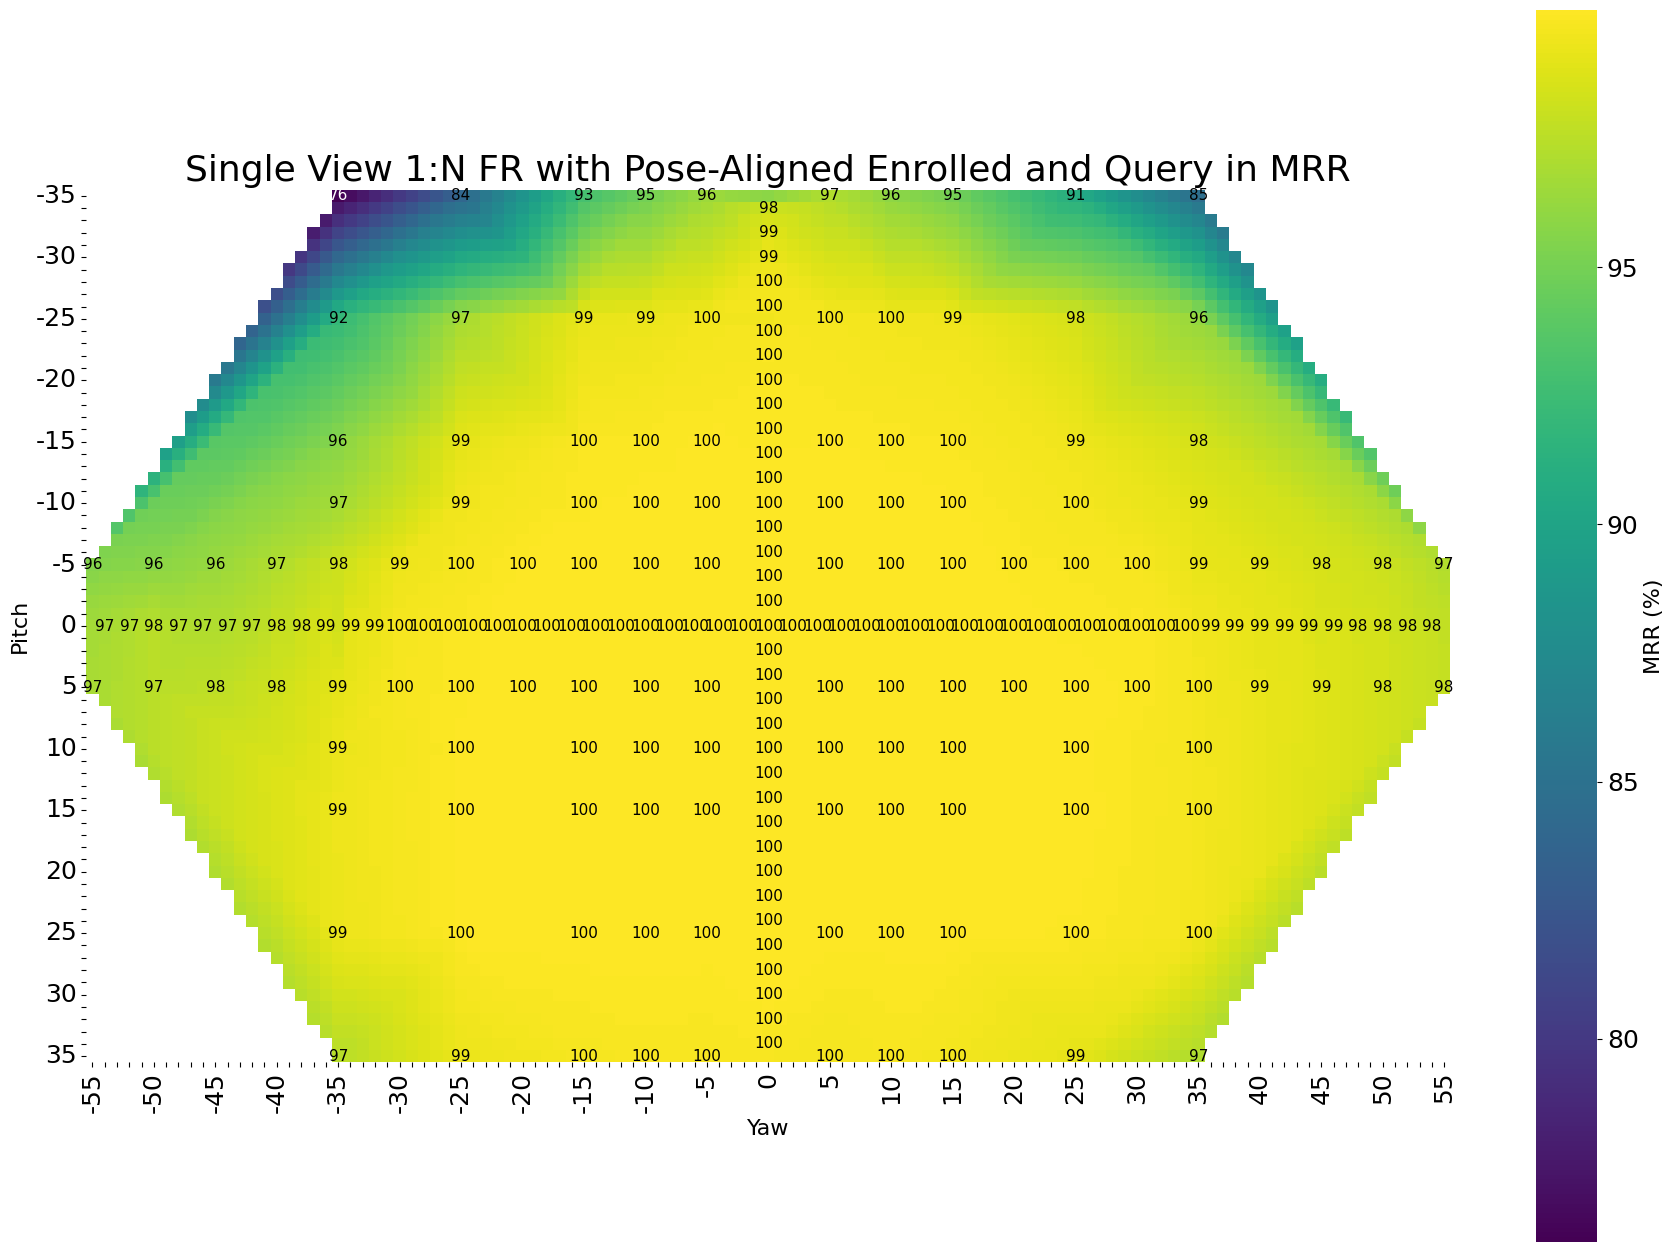

In [10]:
name="test_rgb_bff_crop305_emb-glint_r50"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [20:56<00:00, 14.91it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r100_mrr_heatmap_cache.npz


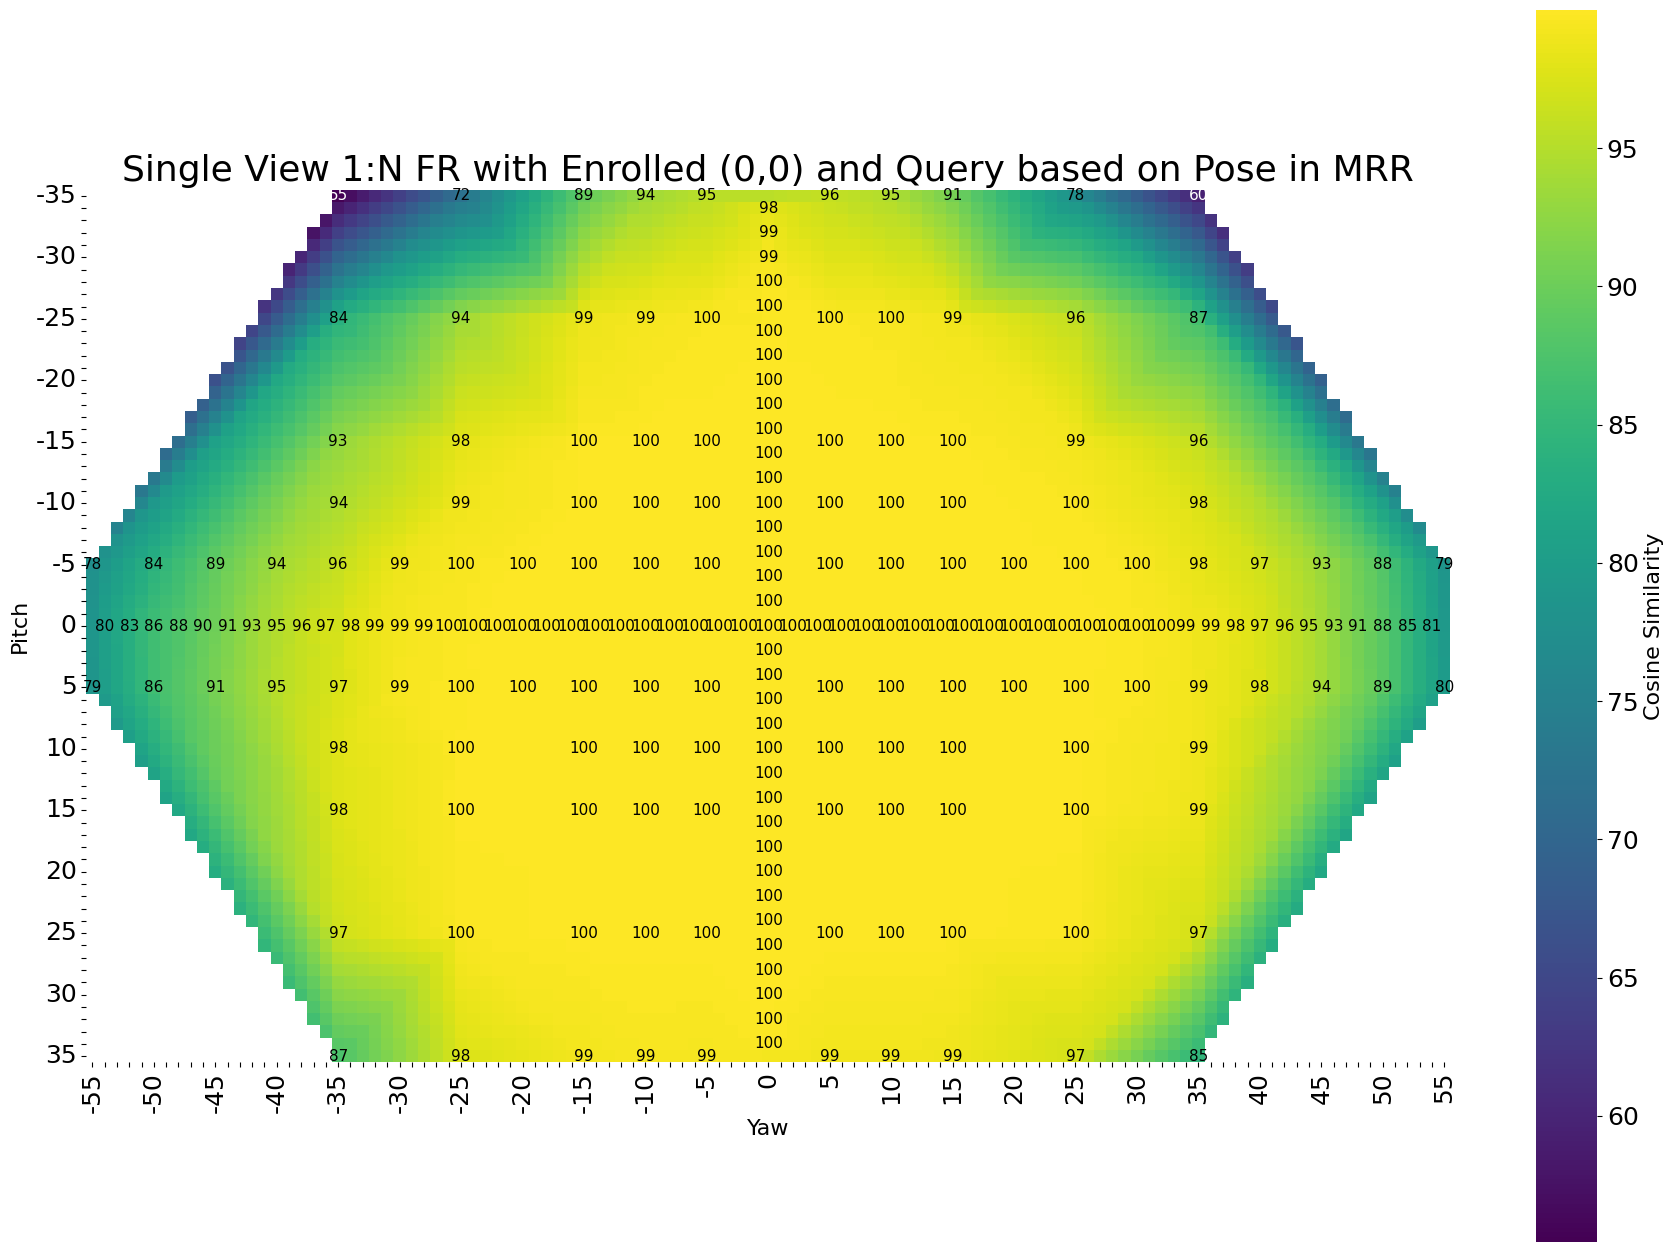

Processing Queries: 100%|██████████| 18745/18745 [21:37<00:00, 14.45it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-glint_r100_mrr_heatmap_cache_samepose.npz


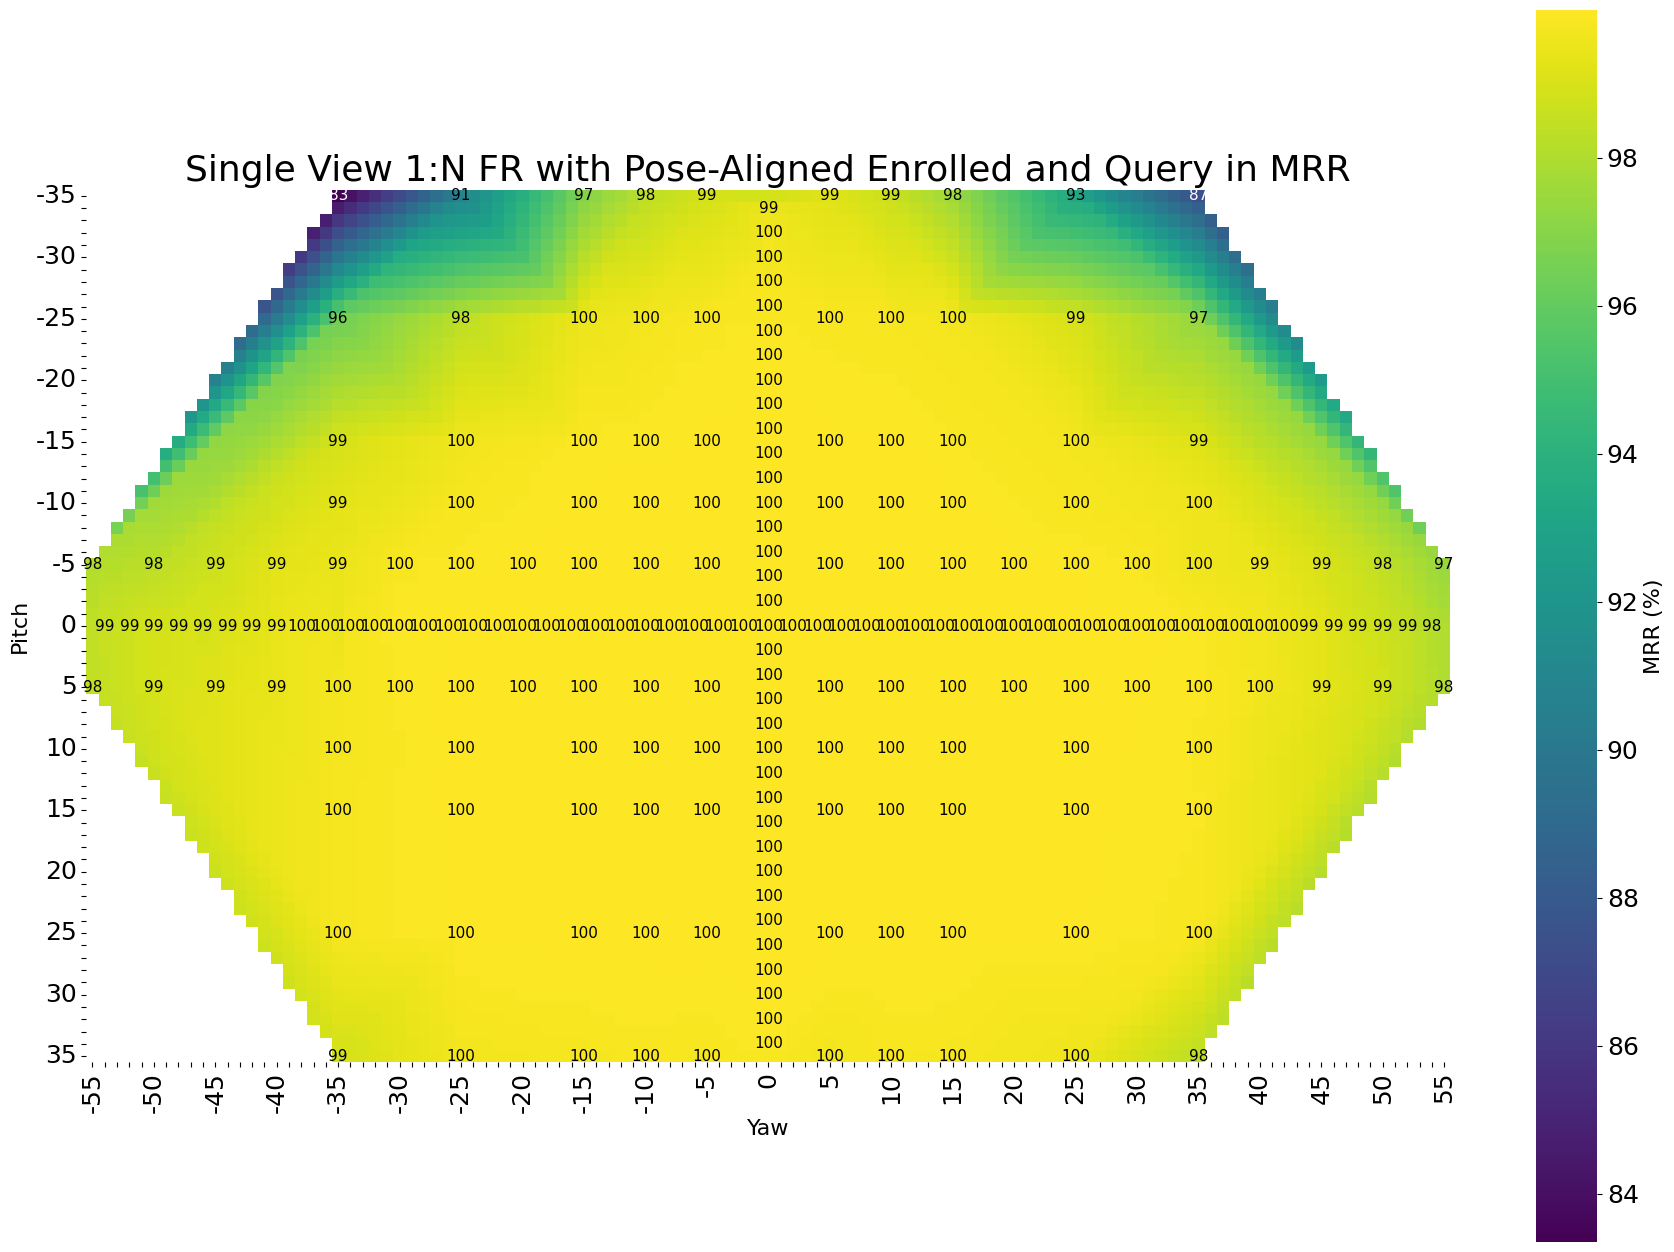

In [11]:
name="test_rgb_bff_crop305_emb-glint_r100"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [19:07<00:00, 16.33it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-ms1mv3_r100_mrr_heatmap_cache.npz


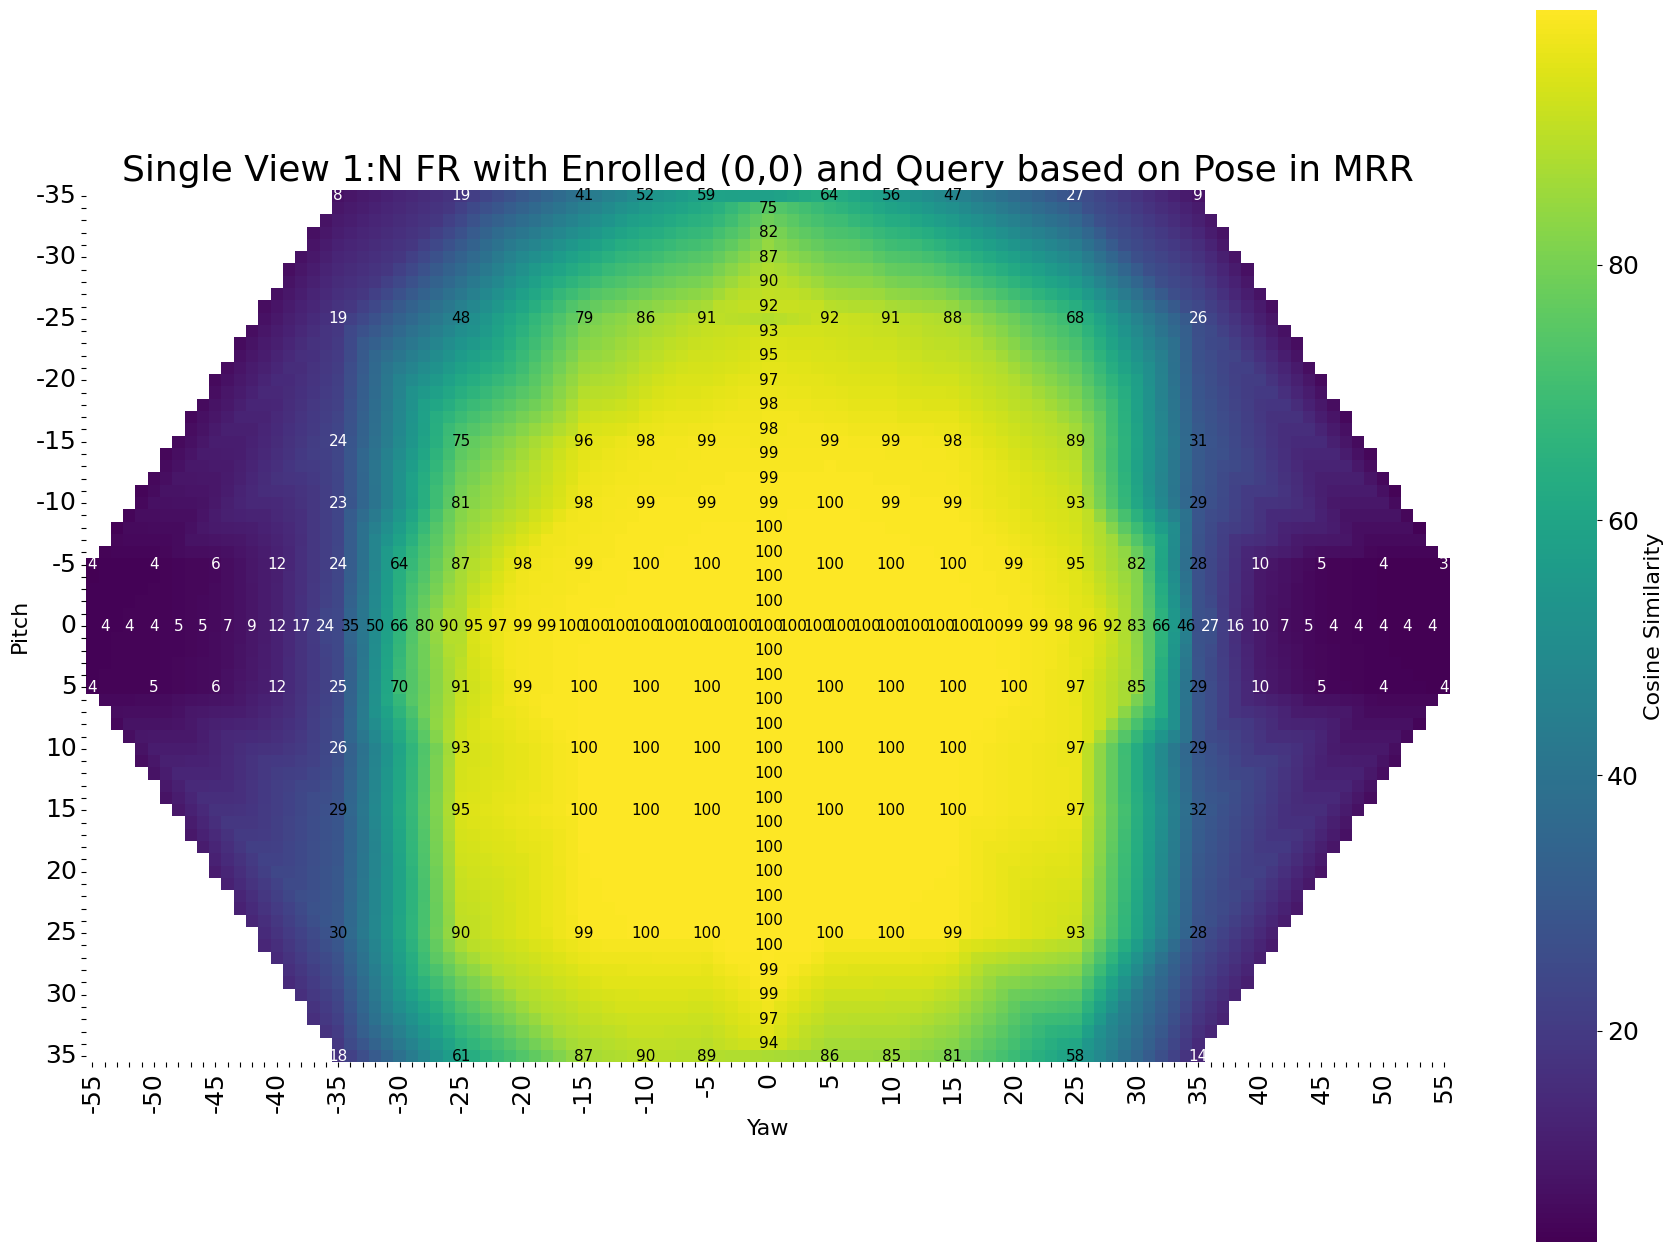

Processing Queries: 100%|██████████| 18745/18745 [21:05<00:00, 14.81it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-ms1mv3_r100_mrr_heatmap_cache_samepose.npz


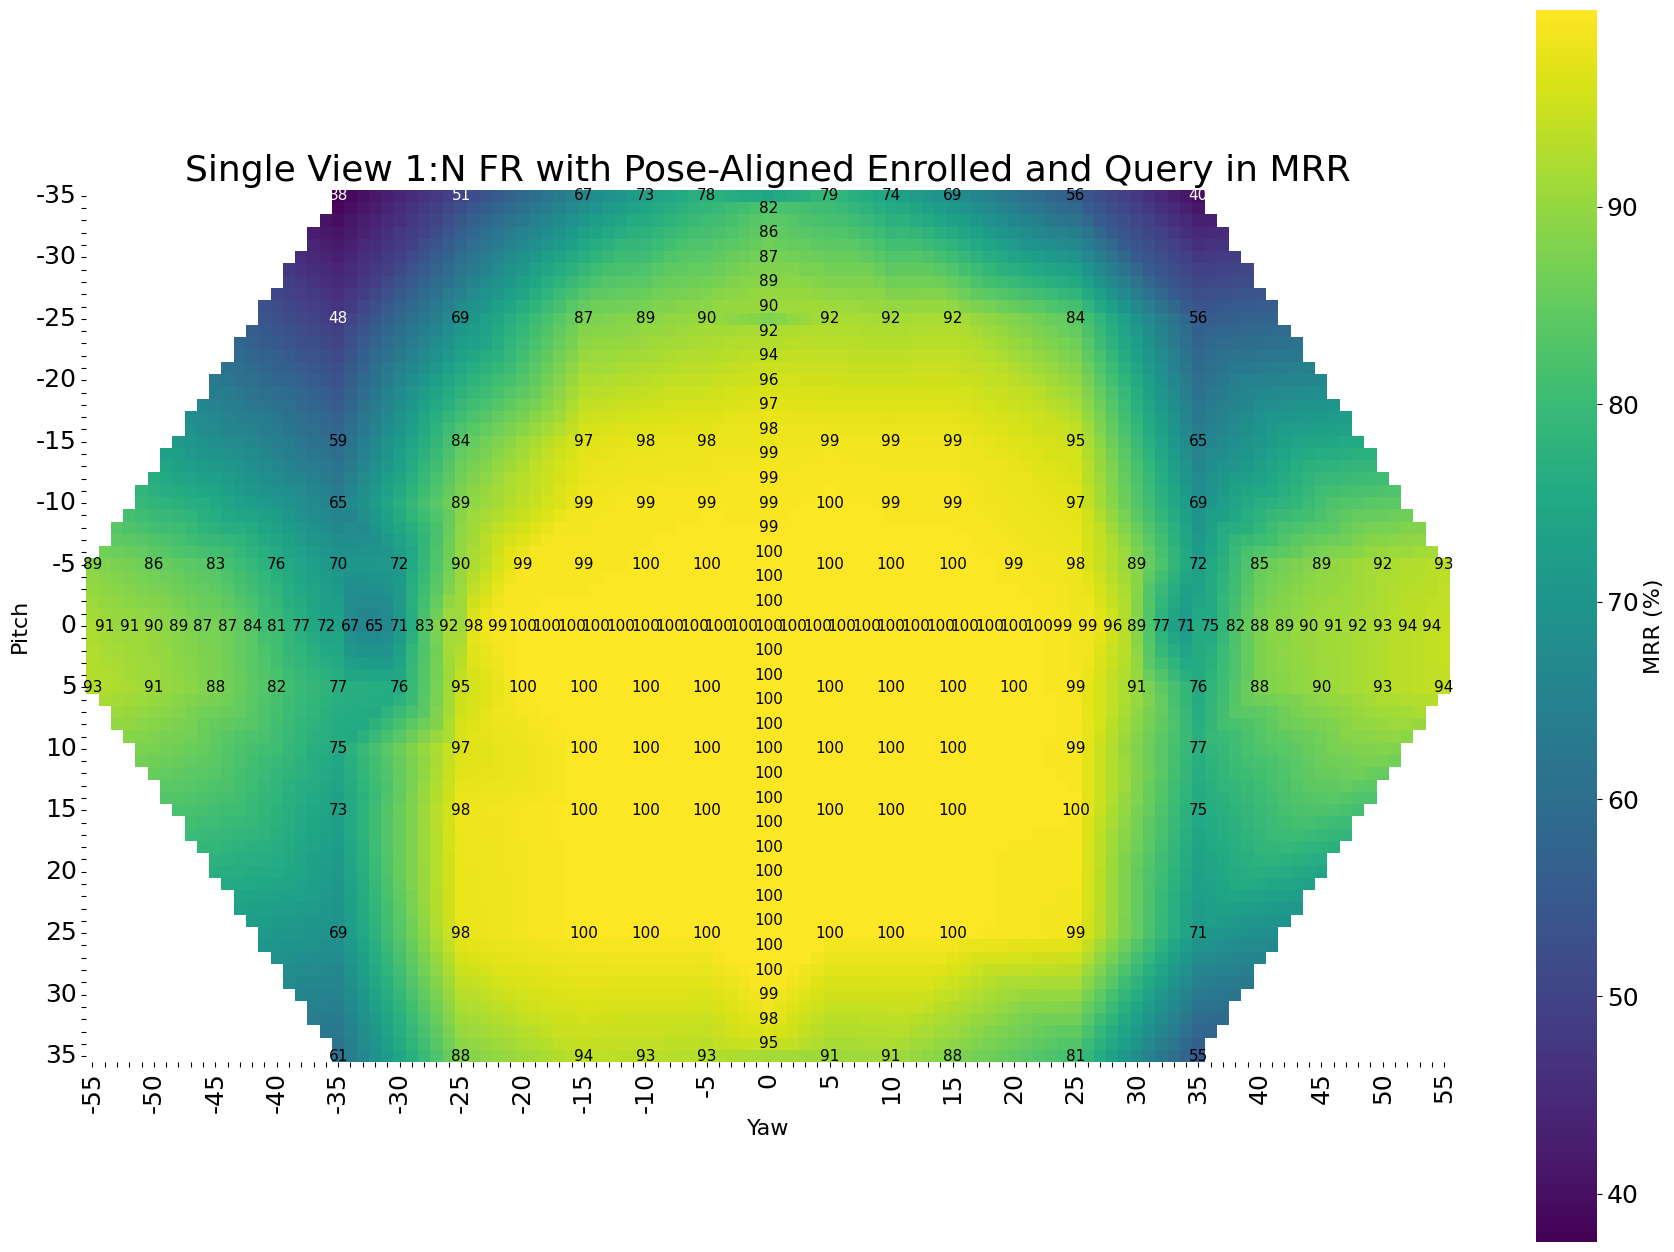

In [12]:
name="test_rgb_bff_crop305_emb-ms1mv3_r100"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [20:08<00:00, 15.51it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-hyperface10k_mrr_heatmap_cache.npz


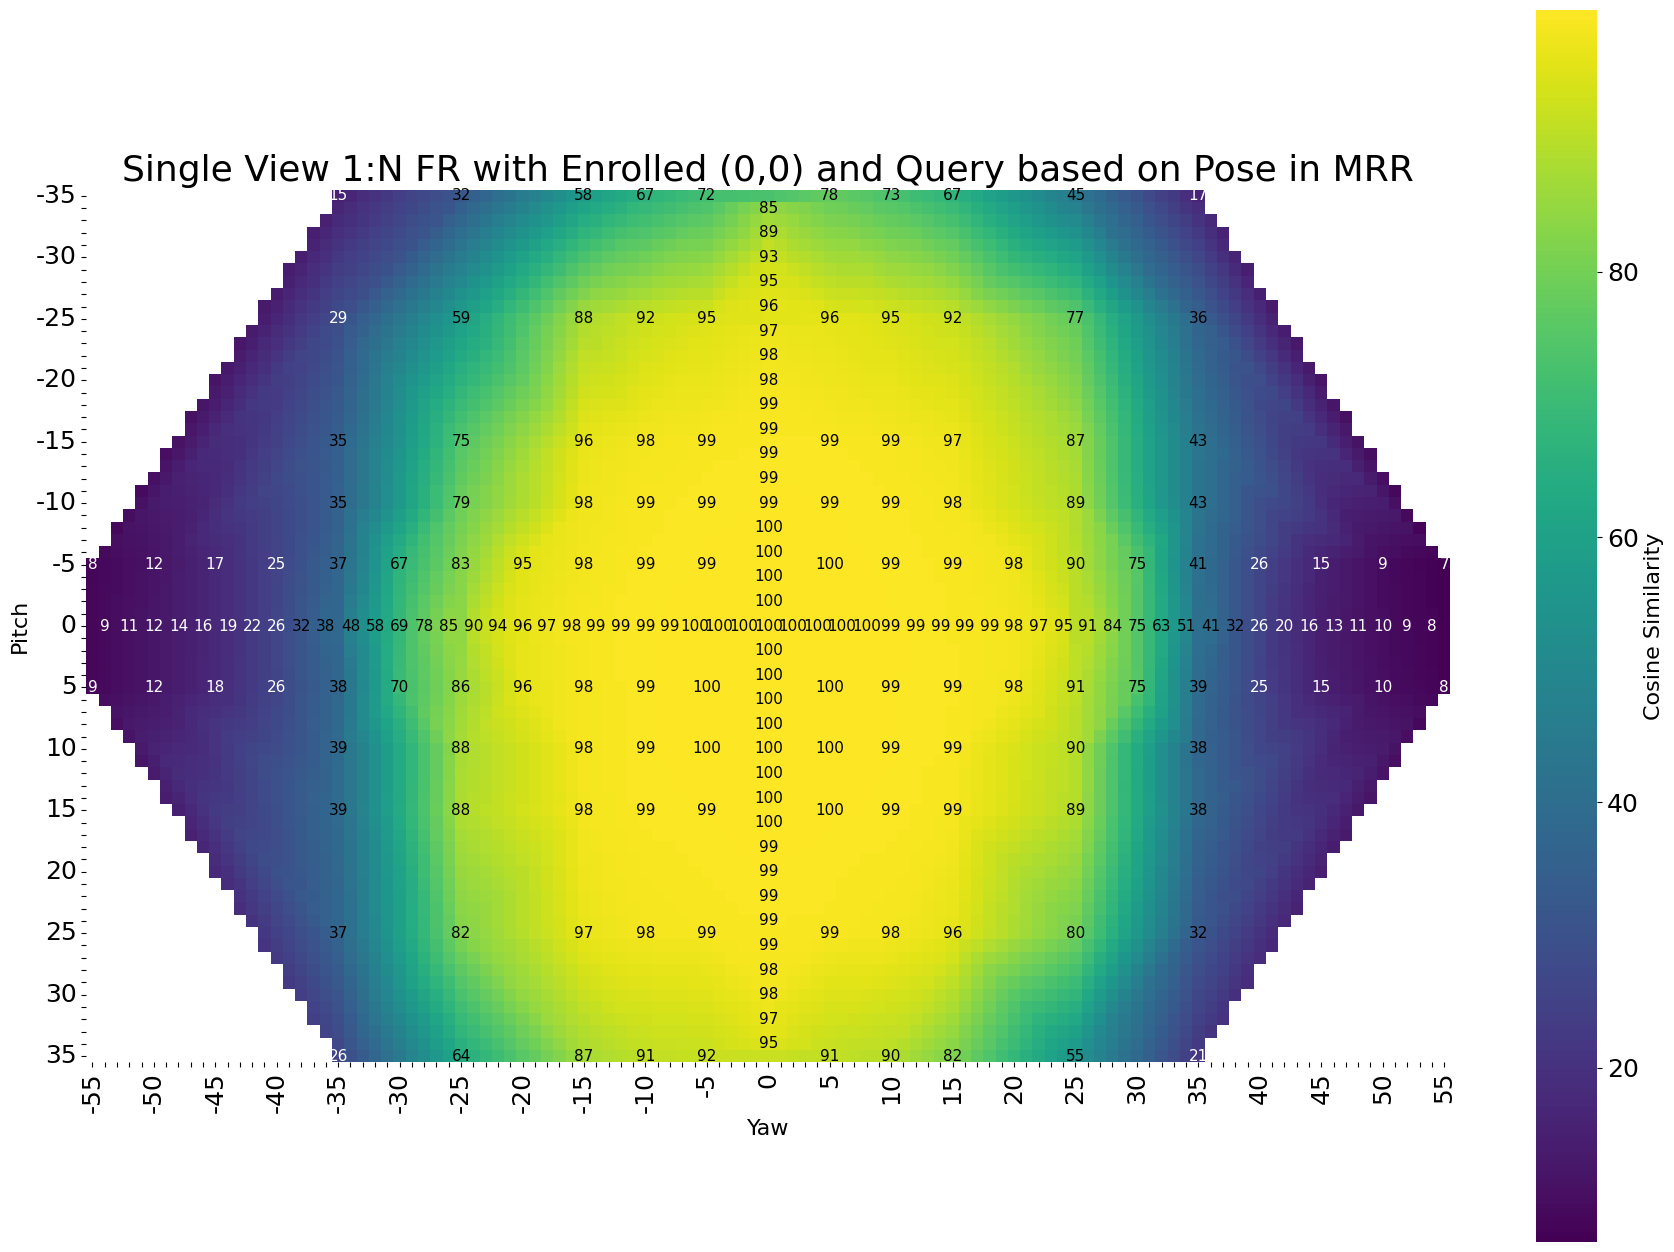

Processing Queries: 100%|██████████| 18745/18745 [21:46<00:00, 14.35it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-hyperface10k_mrr_heatmap_cache_samepose.npz


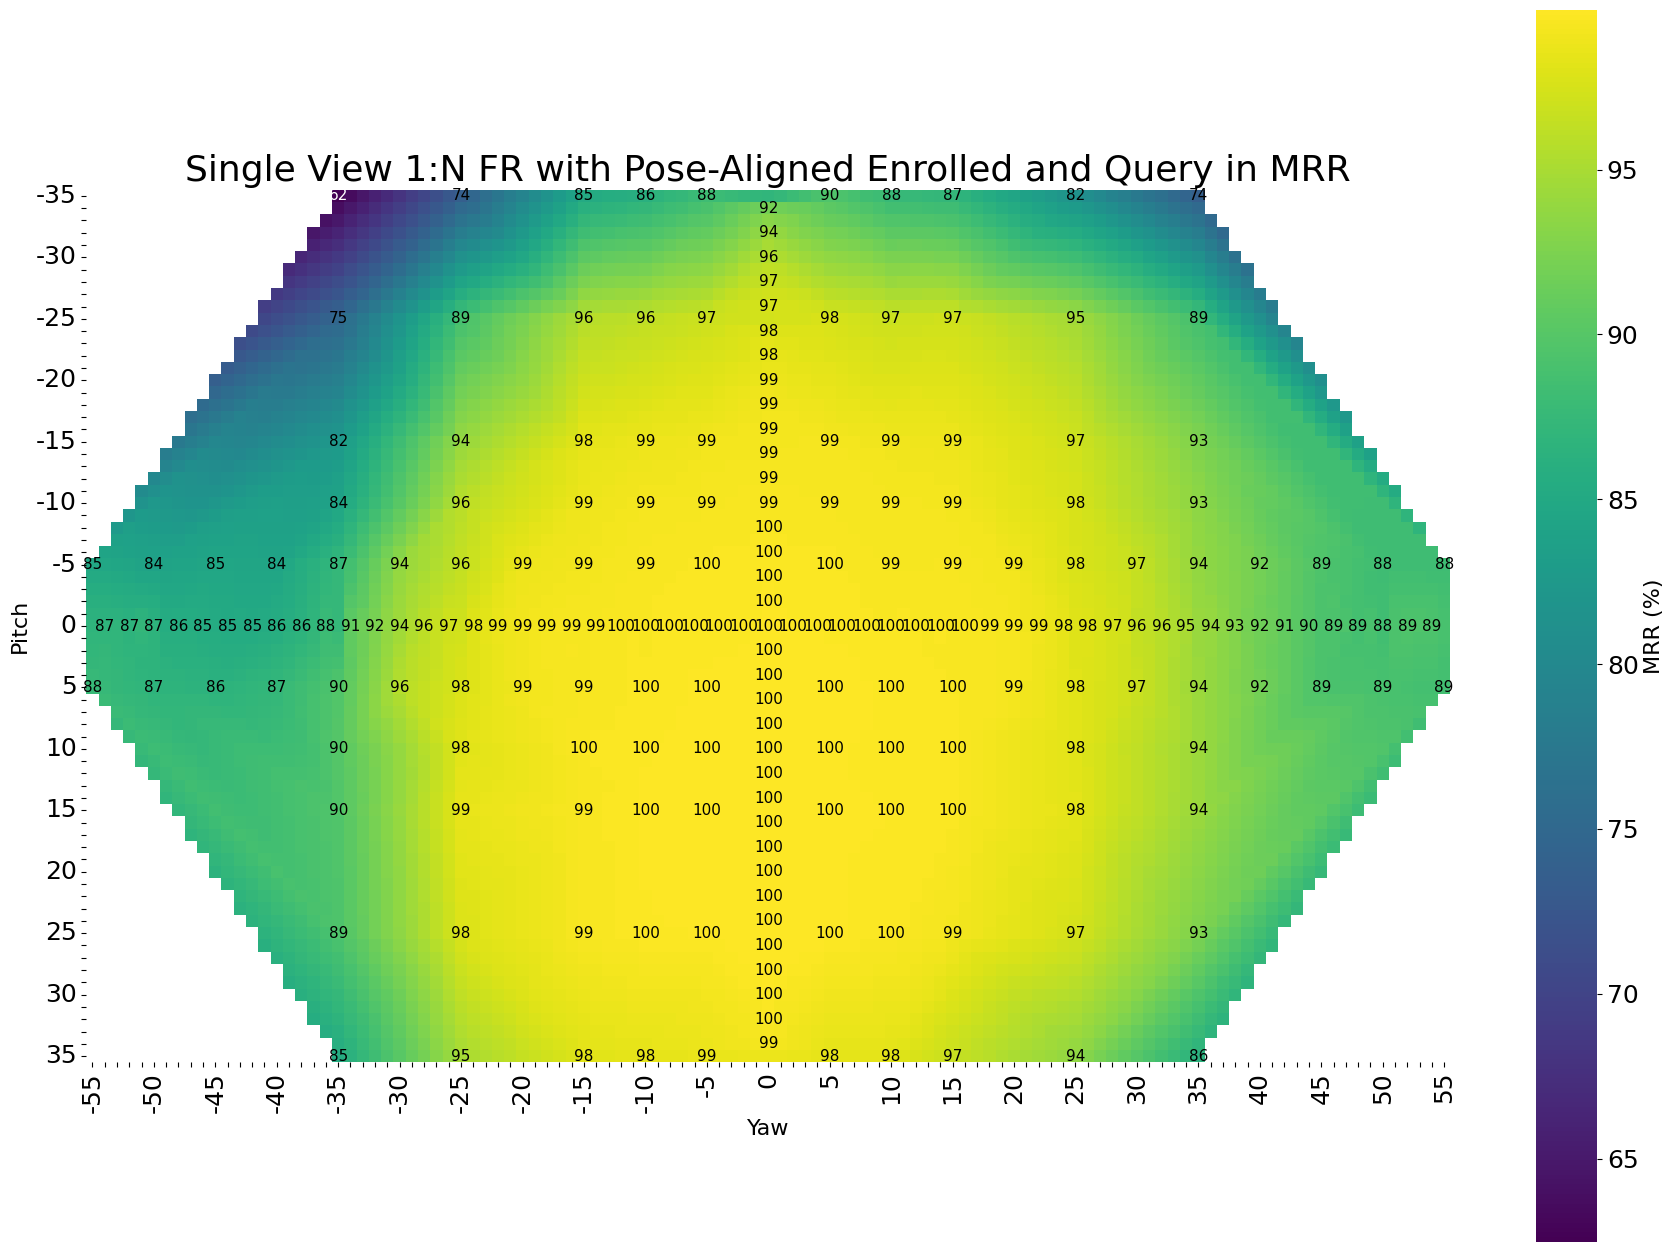

In [13]:
name="test_rgb_bff_crop305_emb-hyperface10k"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)

Processing Queries: 100%|██████████| 18745/18745 [19:28<00:00, 16.04it/s]


Saved heatmap cache: test_rgb_bff_crop305_emb-hyperface50k_mrr_heatmap_cache.npz


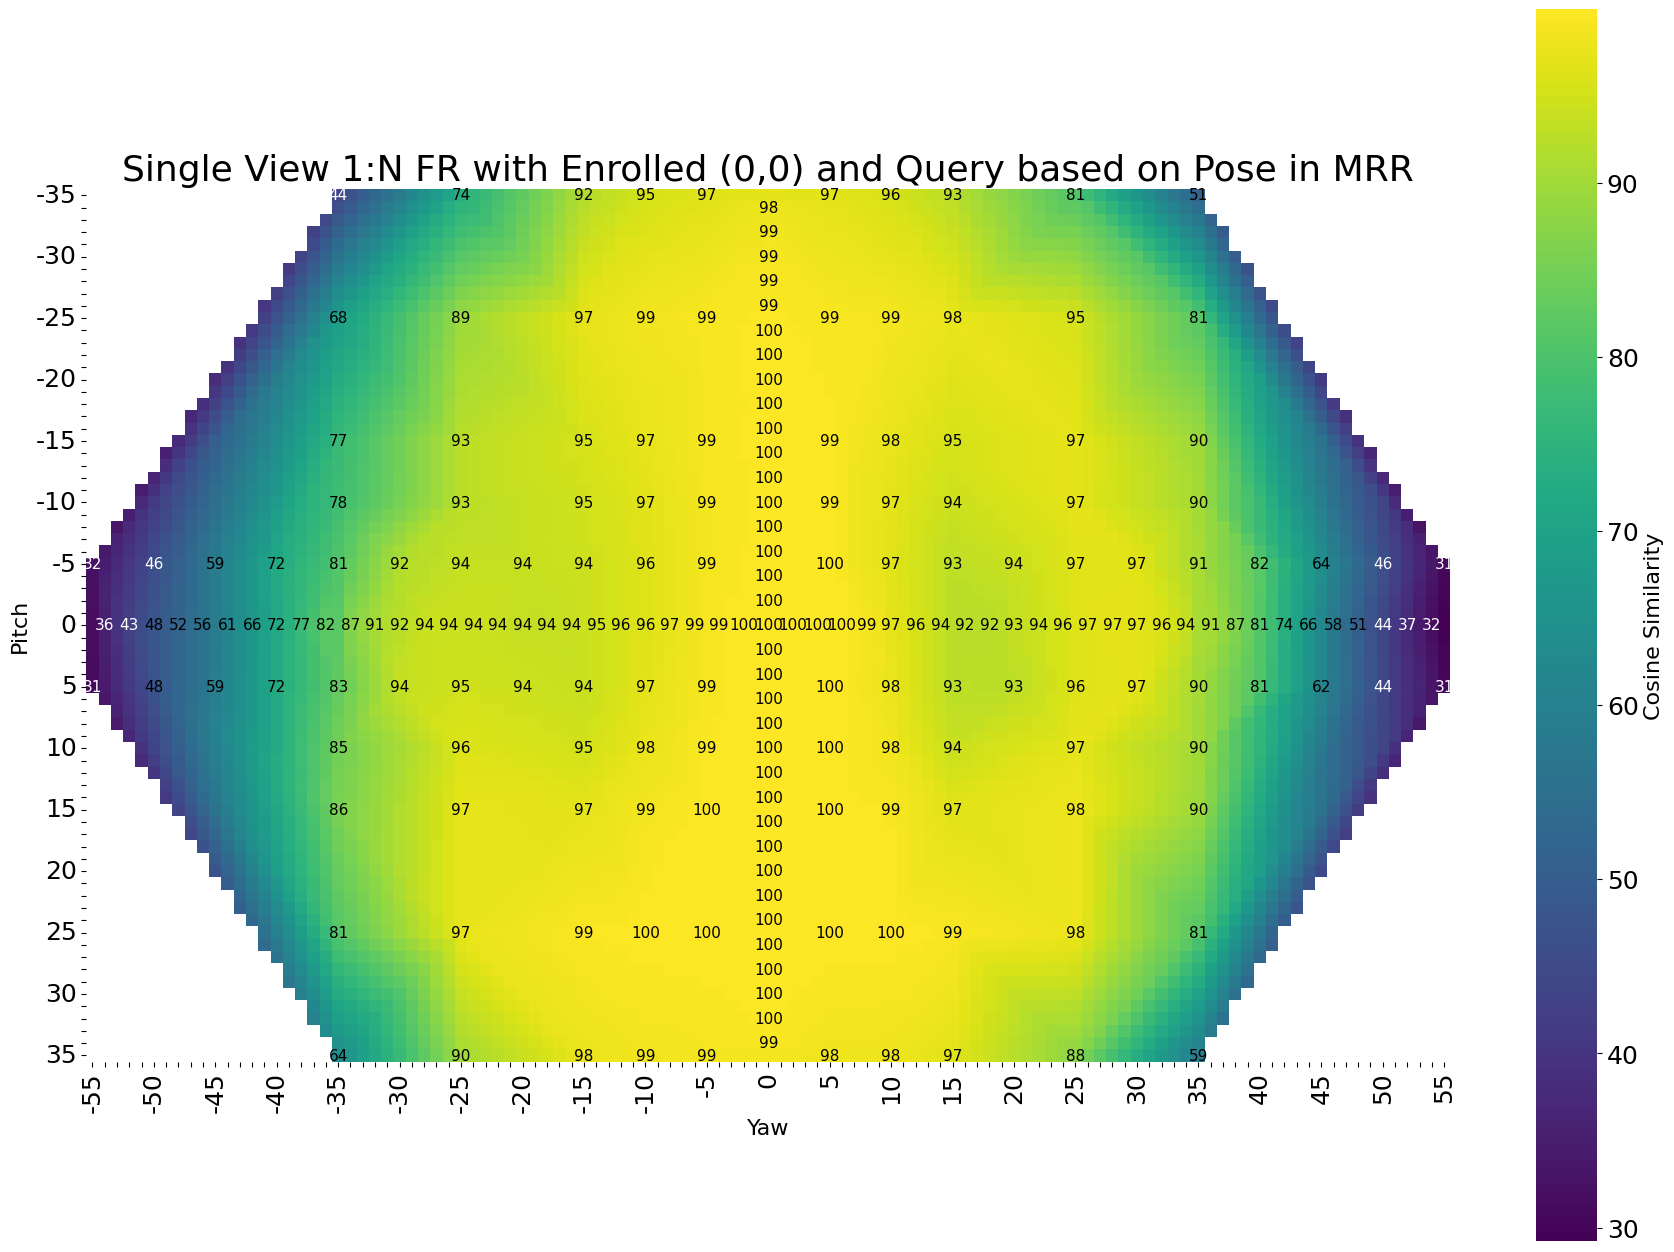

Processing Queries: 100%|██████████| 18745/18745 [22:27<00:00, 13.91it/s]
C:\Users\Eduard-Desktop\AppData\Local\Temp\ipykernel_9632\3372909892.py:120: RuntimeWarning: invalid value encountered in divide
  values = (mrr_sum.ravel() / counts.ravel())[valid] * 100


Saved heatmap cache: test_rgb_bff_crop305_emb-hyperface50k_mrr_heatmap_cache_samepose.npz


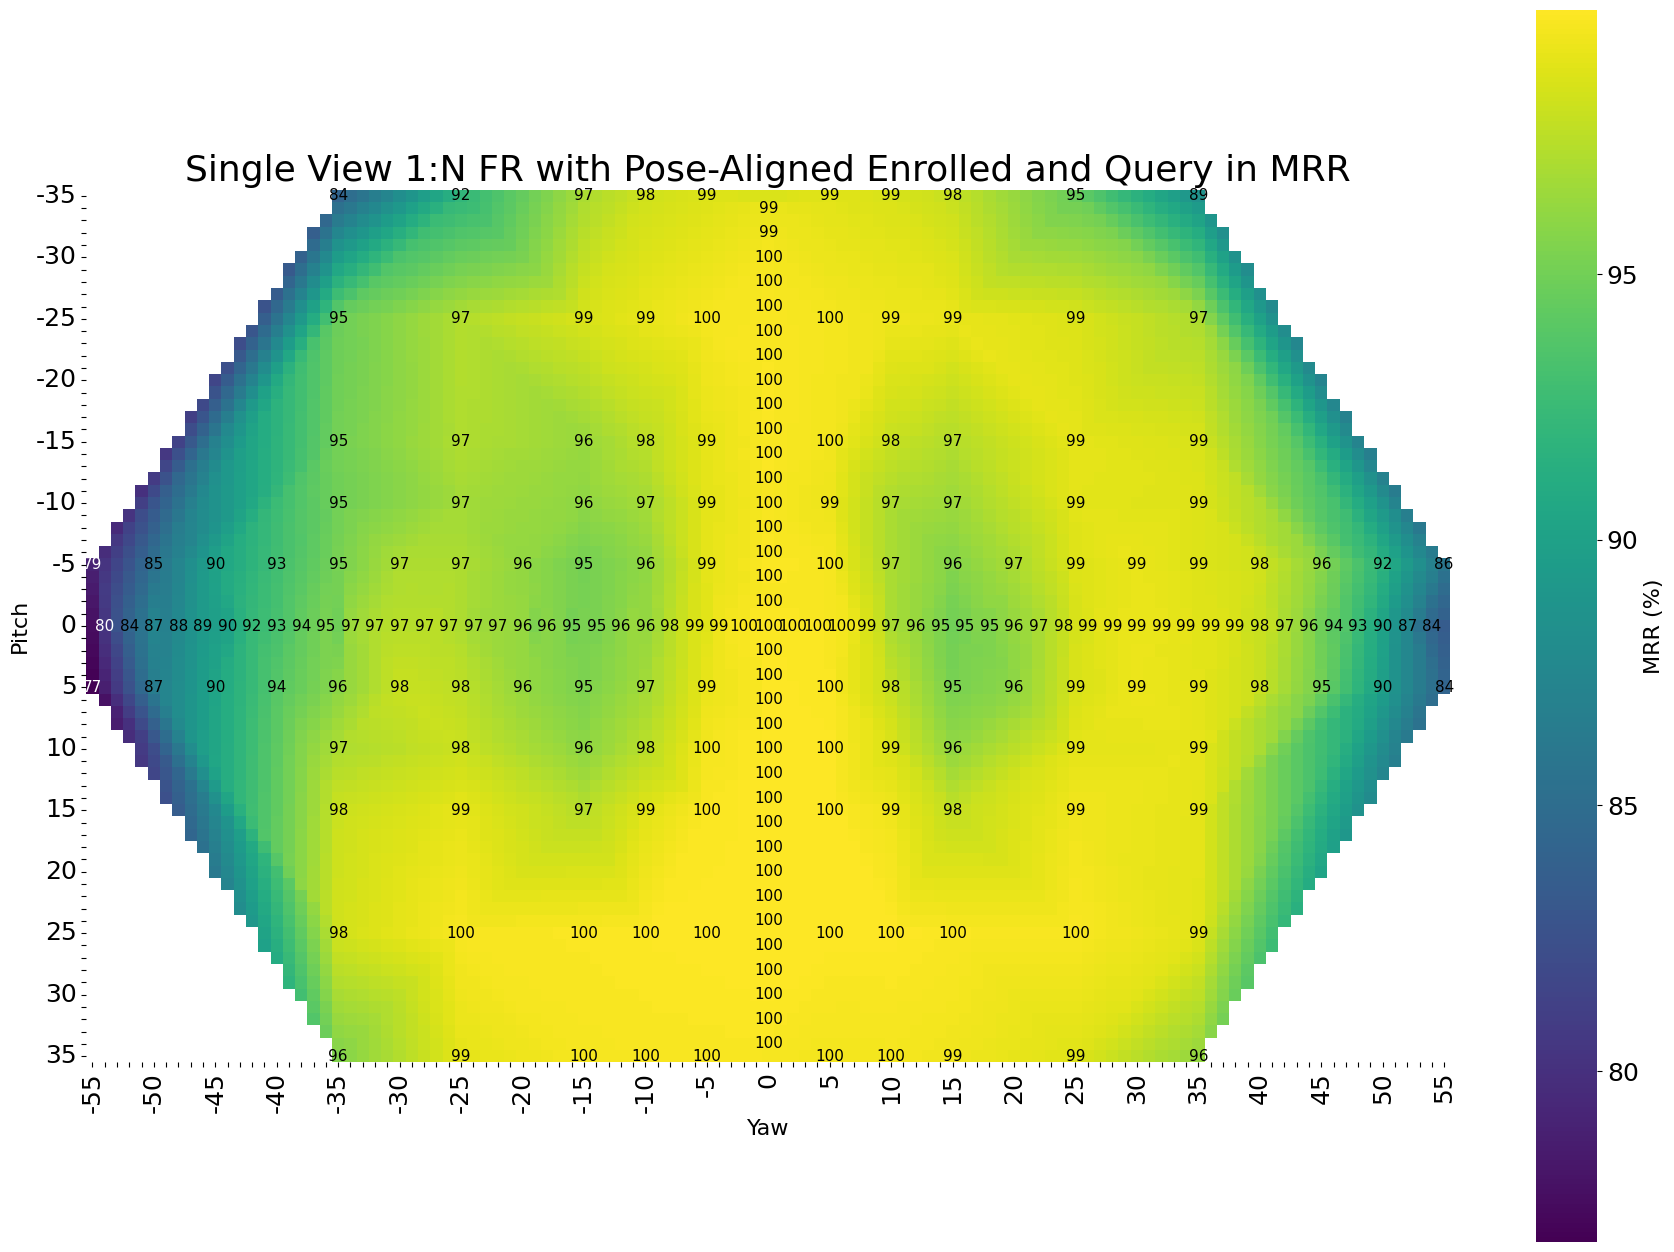

In [14]:
name="test_rgb_bff_crop305_emb-hyperface50k"
dataset_enrolled = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/enrolled/", disable_tqdm=False)
dataset_query = EmbeddingDataset(r"F:/Face/data/dataset16_emb/"+name+r"/query/", disable_tqdm=False)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap(dataset_query, dataset_enrolled, visualize=True, prefix=name)
heatmap_mrr, pitches, yaws = compute_mrr_heatmap_aligned(dataset_query, dataset_enrolled, visualize=True, prefix=name)